# Spatial clustering of CODEX spatial proteomics data
This tutorial shows an example of spatial clustering of a CODEX dataset of mouse spleens from [Goltsev et al., 2018](https://doi.org/10.1016/j.cell.2018.07.010) using CellCharter.
The dataset is composed of 3 healthy samples (BALBc-1 to BALBc-3) and 6 samples from mice with the systmeic lupus erythematosus disease (MRL-4 to MRL-9) for a total of more than 700k cells assyed for around 30 protein markers. <br>
We are going to use trVAE for dimensionality reduction and CellCharter to compute the spatial clusters of all samples together.

IMPORTANT: to decrease the amount of time required to run the notebook, we are running the analysis on the same dataset but with parameters different from the original publication. Hence, the results may slightly differ from the ones reported in the paper. 

Let's first load the packages that will be necessary for the analysis.

In [2]:
# import squidpy as sq
# import cellcharter as cc
import scanpy as sc
import mingl as mg
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import networkx as nx
import seaborn as sns
import numpy as np
import os
from scipy.spatial.distance import cdist
# from lightning.pytorch import seed_everything
# seed_everything(0)

## Data preprocessing

We can download the full dataset directly through CellCharter.

In [16]:
file_path = "/mnt/jwh83-data/MINGLE/Data/Intestine/05_25_HuBMAP_tunit.csv"
cells = mg.pp.read_file(file_path)

/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/mingl/pp/preprocessing.py:33: DtypeWarning: Columns (62,63,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [20]:
import numpy as np
import pandas as pd
import anndata as ad
import squidpy as sq
import cellcharter as cc

# Use all cells with valid cell-type labels
obs = cells.obs.dropna(subset=["Cell Type"]).copy()

# Convert cell-type labels to one-hot features
celltype_features = pd.get_dummies(
    obs["Cell Type"].astype(str),
    dtype=np.float32
)

adata_full = ad.AnnData(
    X=celltype_features.to_numpy(dtype=np.float32),
    obs=obs
)

adata_full.var_names = celltype_features.columns.astype(str)

# Add spatial coordinates
adata_full.obsm["spatial"] = obs[["x", "y"]].to_numpy(
    dtype=np.float32
)

print(adata_full)

AnnData object with n_obs × n_vars = 2512002 × 25
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit'
    obsm: 'spatial'


We are now going to scale the intensity values of each marker individually using scanpy's `pp.scale` function.

First, we save the unscaled data in the raw version of our anndata object, so that we can retrieve it any time.<br>
Then, each sample will be scaled indepenendently. However, scanpy does not implement this functionality, so we will do it manually.


In [ ]:
# adata.raw = adata_full.copy()
# for sample in adata_full.obs['unique_region'].cat.categories:
#     adata_full.X[adata_full.obs['unique_region'] == sample, :] = sc.pp.scale(adata_full[adata_full.obs['unique_region'] == sample], copy=True).X

AttributeError: Can only use .cat accessor with a 'category' dtype

this is scaling per sample above, so switch to global scaling and change to not be categorical label

In [21]:
# Save the original, unscaled data
adata_full.raw = adata_full.copy()

# Scale each marker across all cells
sc.pp.scale(adata_full)


## Dimensionality reduction


Given the limited number of markers in current spatial proteomics technologies, dimensionality reduction is not stricly necessary. However, we noticed that it can help in reducing noise and speed up the clustering step. This is crucial especially in the cluster stability analysis, that, to suggest the best candidates for the number of clusters, repeats the clustering multiple times.

We are going to use a trVAE model already pretrained on this dataset.<br>
First we load the model. In `map_location` you can specify the device in which you want to load the model. This allows to load, for example, to load on CPU a model trained on a GPU.
In fact, this model was trained on a GPU, but we are going to load it on the CPU.


In [ ]:
# model = cc.tl.TRVAE.load('./tutorial_models/codex_mouse_spleen_trvae', adata, map_location='cpu')

/mnt/etemp/varrone/mamba_envs/cellcharter-dev/lib/python3.11/site-packages/scarches/models/base/_base.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state_dict 

AnnData object with n_obs × n_vars = 707474 × 29
    obs: 'cell_type', 'i-niche', 'tile', 'area', 'dataset', 'stage', 'sample'
    uns: 'spatial', 'spatial_cluster_colors'
    obsm: 'blanks', 'spatial'

INITIALIZING NEW NETWORK..............
Encoder Architecture:
	Input Layer in, out and cond: 29 128 1
	Hidden Layer 1 in/out: 128 128
	Mean/Var Layer in/out: 128 10
Decoder Architecture:
	First Layer in, out and cond:  10 128 1
	Hidden Layer 1 in/out: 128 128
	Output Layer in/out:  128 29 



Then we are going to extract the dimensionality-reduced embeddings for all cells of the dataset. We use the `dataset` labels, which are the same for all cells of this dataset, as condition, because there was no need to correct for batch effects.


In [ ]:
# adata.obsm['X_trVAE'] = model.get_latent(adata.X, adata.obs['dataset'])

If you are using a different dataset, you will have to train your own trVAE model. You can do it using `cc.tl.TRVAE`, a slightly modified version of the original trVAE model from [scArches](https://docs.scarches.org/en/latest/).

Apart from internal changes, the model has the same interface as the original one, so you can rely on the documentation of the original model for any further information.

do PCA here instead for dimensionality reduction

In [22]:
# Run PCA
sc.tl.pca(adata_full, n_comps=20)

# PCA coordinates are stored in:
adata_full.obsm["X_pca"]

array([[-0.24185589, -0.39918774, -0.08033758, ...,  0.10195702,
         0.52783495,  0.6785005 ],
       [-0.24187252, -0.39934015, -0.08019725, ...,  0.10285201,
         0.52756625,  0.67853814],
       [-0.2418434 , -0.39944366, -0.08025333, ...,  0.10180692,
         0.5275197 ,  0.67853844],
       ...,
       [-0.2549304 , -0.4315218 , -0.09151756, ..., -0.16222578,
        -0.5212496 , -0.43803656],
       [-0.2549304 , -0.4315218 , -0.09151756, ..., -0.16222575,
        -0.52124953, -0.43803656],
       [-0.2643037 , -0.45556378, -0.10088963, ..., -0.06033176,
        -0.22588672, -0.21031934]], shape=(2512002, 20), dtype=float32)

switch unique_region to categorical

In [25]:
adata_full.obs["unique_region"] = adata_full.obs["unique_region"].astype("category")

## CellCharter's spatial clustering
It's now time to compute the spatial clusters.<br>
CellCharter encodes all cells of each sample as a network. Every cell is a node and two cells are connected by an edge if they are physically close to each other in the tissue.
We can obtain this network using squidpy's `gr.spatial_neighbors` function.

In [26]:
sq.gr.spatial_neighbors(adata_full, library_key='unique_region', coord_type='generic', delaunay=True)

INFO     Creating graph using `None` transform and `64` libraries.                                                 


/tmp/ipykernel_2432535/457606604.py:1: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata_full, library_key='unique_region', coord_type='generic', delaunay=True)


In [27]:
adata_full.obs['unique_region'].unique()

['B004_Ascending', 'B005_Ascending', 'B006_Ascending', 'B009_Right', 'B010_Right', ..., 'B009_Trans', 'B010_Trans', 'B011_Trans', 'B012_Trans', 'B008_Trans']
Length: 64
Categories (64, object): ['B004_Ascending', 'B004_Descending', 'B004_Descending - Sigmoid', 'B004_Duodenum', ..., 'B012_Proximal jejunum', 'B012_Right', 'B012_Sigmoid', 'B012_Trans']

In [29]:
adata_full

AnnData object with n_obs × n_vars = 2512002 × 25
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit'
    var: 'mean', 'std'
    uns: 'pca', 'spatial_neighbors', 'unique_region_colors'
    obsm: 'spatial', 'X_pca'
    v

However, the Delaunay triangulation used by squidpy has the drawback of generating connections between distant cells.<br>
We can see it by zooming in one area of the BALBc-3 sample.

In [ ]:
# sq.pl.spatial_scatter(
#     adata_full,
#     color="unique_region",
#     library_key="unique_region",
#     library_id="B004_Ascending",
#     spatial_key="spatial",
#     img=None,
#     title="B004_Ascending",
#     size=2500,
#     connectivity_key="spatial_connectivities",
#     edges_width=0.3,
#     legend_loc=None,
#     crop_coord=None
# )


One could decide a maximum radius and pass it as a parameter to the function, but it depends from dataset to dataset based on the spatial resolution of the data. We developed a method called gr.remove_longLinks that removes links that have a distance greater than a certain percentile (the default is the 99th percentile). We can see that it greatly reduces the long links without affecting the rest.

In [33]:
cc.gr.remove_long_links(adata_full)

In [ ]:
# sq.pl.spatial_scatter(
#     adata, 
#     color='sample', 
#     library_key='sample', 
#     img=None, 
#     title=['BALBc-3'],
#     size=2500,
#     connectivity_key='spatial_connectivities',
#     edges_width=0.3,
#     legend_loc=None,
#     crop_coord=(900000, 900000, 1700000, 1700000 ),
#     library_id=['BALBc-3']
#     )

The next step is the neighborhood aggregation. It consists of concatenating the features of every cell with the features aggregated from neighbors ad increasing layers from the considered cell, up to a certain layer `n_layers`. Aggregation functions are used to obtain a single feature vector from the vectors of multiple neighbors, with the default being the `mean` function.

In this case we use 3 layers of neighbors, so we obtain, for each cell, a feature vector of length 40. That is the cell's reduced vector size from trVAE (10) plus the 3 aggregated vectors of length 10 each, from the 3 layers of neighbors.

In [34]:
cc.gr.aggregate_neighbors(
    adata_full,
    n_layers=4,
    use_rep="X_pca"
)


100%|██████████| 5/5 [00:16<00:00,  3.21s/it]


We create the Gaussian Mixture model, specifying 11 as desired number of clusters. This value was obtained from the cluster stability analysis. For more details, you can check our paper.

In [ ]:
# gmm = cc.tl.Cluster(
#     n_clusters=11, 
#     random_state=12345,
#     # If running on GPU
#     #trainer_params=dict(accelerator='gpu', devices=1)
# )

use the functionality to allow model to find best number of neighborhoods

In [37]:
autok = cc.tl.ClusterAutoK(
    n_clusters=(15, 25),
    max_runs=1,
    convergence_tol=0.001,
)

autok.fit(
    adata_full,
    use_rep="X_cellcharter"
)


Iteration 1/1


  0%|          | 0/13 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEV

In [39]:
print("n_clusters:", autok.n_clusters)
print("stability:", autok.stability)
print("peaks:", getattr(autok, "peaks", None))
print("best_k:", getattr(autok, "best_k", None))


n_clusters: [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
stability: None


ValueError: Cannot compute stability with max_runs <= 1

In [40]:
print(autok.__dict__.keys())


dict_keys(['n_clusters', 'max_runs', 'convergence_tol', 'model_class', 'model_params', 'similarity_function', 'stability', 'labels', 'best_models'])


In [41]:
for key, value in autok.__dict__.items():
    print(key, type(value))


n_clusters <class 'list'>
max_runs <class 'int'>
convergence_tol <class 'float'>
model_class <class 'abc.ABCMeta'>
model_params <class 'dict'>
similarity_function <class 'function'>
stability <class 'NoneType'>
labels <class 'collections.defaultdict'>
best_models <class 'dict'>


In [42]:
print("max_runs:", autok.max_runs)
print("n_clusters:", autok.n_clusters)


max_runs: 1
n_clusters: [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]


In [43]:
print(autok.best_models.keys())
print({k: len(v) for k, v in autok.labels.items()})


dict_keys([14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26])
{14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1}


In [44]:
for k in autok.n_clusters:
    labels = autok.labels[k][0]
    print(
        f"K={k}: "
        f"{len(set(labels))} clusters, "
        f"sizes={np.bincount(labels)}"
    )


K=14: 14 clusters, sizes=[ 17869  21381  32001 349684 440214 117016 240082 141500 163157 128316
 154575 358764 264597  82846]
K=15: 15 clusters, sizes=[ 76899 279465  82846 300116 127595 163157 361466 161753 180746 146304
 300446  21381 117016  64496 128316]
K=16: 16 clusters, sizes=[229701 265584 278662  80213 128316 112475 488194  21825 159756 117016
  76899 175270  32001 227526  64496  54068]
K=17: 17 clusters, sizes=[ 76899 266028 178347 149890  79695 463691 339589  64496 163157 128316
 175253 146142 117016  29627  58255  21381  54220]
K=18: 18 clusters, sizes=[160633 238132 191461 270077 108477  35499  96451 128316  33829  21825
  76899 117016  81497  17869 103905 333190 196455 300471]
K=19: 19 clusters, sizes=[ 64496 204693 156898 261856 157187 253282 130273 128316  21381 256698
  33829  79631 154111  76867  76899 123304 117016 158017  57248]
K=20: 20 clusters, sizes=[ 21825 170224 281637 438946 145320 144020  76899 128316  64496 112475
 163157  81681 374035  32001  57248  17869 

In [45]:
from sklearn.metrics import adjusted_rand_score

for k in range(14, 26):
    labels1 = autok.labels[k][0]
    labels2 = autok.labels[k + 1][0]

    ari = adjusted_rand_score(labels1, labels2)

    print(f"K={k} vs K={k+1}: ARI = {ari:.4f}")


K=14 vs K=15: ARI = 0.4418
K=15 vs K=16: ARI = 0.5134
K=16 vs K=17: ARI = 0.5082
K=17 vs K=18: ARI = 0.5766
K=18 vs K=19: ARI = 0.5801
K=19 vs K=20: ARI = 0.6449
K=20 vs K=21: ARI = 0.7353
K=21 vs K=22: ARI = 0.9336
K=22 vs K=23: ARI = 0.8309
K=23 vs K=24: ARI = 0.6553
K=24 vs K=25: ARI = 0.7338
K=25 vs K=26: ARI = 0.6931


In [46]:
for k in [21, 22, 23]:
    adata_full.obs[f"cc_K{k}"] = autok.labels[k][0].astype(str)


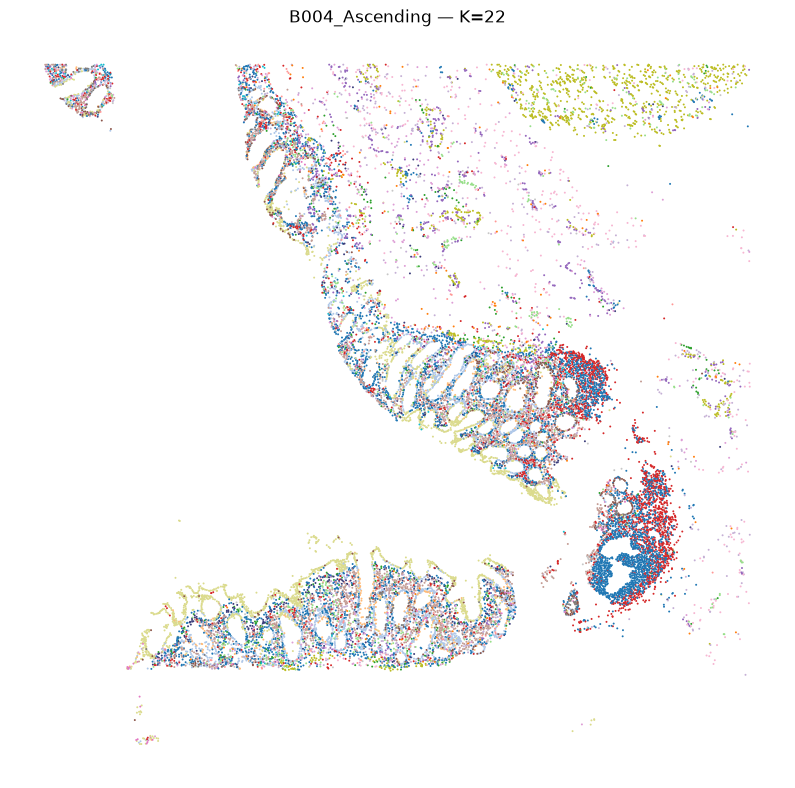

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

region = "B004_Ascending"
mask = adata_full.obs["unique_region"] == region

coords = adata_full.obsm["spatial"][mask]
labels = adata_full.obs.loc[mask, "cc_K22"].astype("category")

colors = plt.cm.tab20(np.linspace(0, 1, 20))
colors = np.vstack([colors, plt.cm.tab20b(np.linspace(0, 1, 2))])

cmap = mcolors.ListedColormap(colors)

plt.figure(figsize=(10, 10))

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=labels.cat.codes,
    cmap=cmap,
    s=2,
    linewidths=0,
    rasterized=True
)

plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()
plt.title(f"{region} — K=22")
plt.axis("off")

plt.show()


In [51]:
adata_full.obs["spatial_cluster"] = autok.labels[22][0].astype(str)


In [52]:
# Check cluster sizes
print(
    adata_full.obs["spatial_cluster"]
    .value_counts()
    .sort_index()
)

spatial_cluster
0     220512
1     247247
10    163157
11    128316
12     57248
13    136710
14     79096
15     32001
16    275565
17    346674
18     29627
19     21381
2      33829
20     21825
21     76832
3      17869
4      64496
5      76899
6     117016
7     111562
8     141665
9     112475
Name: count, dtype: int64


Then we fit the model to the data and predict the cluster label of all cells.

In [ ]:
# gmm.fit(adata, use_rep='X_cellcharter')
# adata.obs['spatial_cluster'] = gmm.predict(adata, use_rep='X_cellcharter')

Epoch 45: 100%|██████████| 1/1 [00:00<00:00,  1.12it/s, nll=21.30]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  2.57it/s]


we already did this above, picked the one with the highest API

We can visualize the spatial clusters for some samples. In this case, we chose a healthy sample, and samples from the early, intermediate and late stage.

In [ ]:
# sq.pl.spatial_scatter(
#     adata, 
#     color='spatial_cluster', 
#     library_key='sample', 
#     img=None, 
#     title=['BALBc-1', 'MRL-4 (early)', 'MRL-8 (intermediate)', 'MRL-9 (late)'],
#     size=2500,
#     ncols=1,
#     library_id=['BALBc-1', 'MRL-4', 'MRL-8', 'MRL-9'],
# )

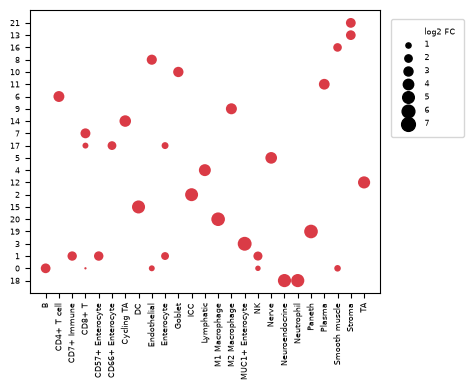

In [53]:
# Calculate enrichment of cell types within each spatial neighborhood
cc.gr.enrichment(
    adata_full,
    group_key="spatial_cluster",
    label_key="Cell Type"
)

cc.pl.enrichment(
    adata_full,
    group_key="spatial_cluster",
    label_key="Cell Type",
    figsize=(4, 4),
    fontsize=6,
    dot_scale=1
)

In [ ]:
# cc.gr.enrichment(adata, group_key='spatial_cluster', label_key='cell_type')
# cc.pl.enrichment(adata, group_key='spatial_cluster', label_key='cell_type', figsize=(4,4), fontsize=6, dot_scale=1)


Plot our way now.

In [54]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import mingl as mg

from mingl.tl import centroids, gmm, edges, grad
from mingl.pl import cell_composition, enrichment

In [64]:
cells_mingl = adata_full.copy()

# Add CellCharter neighborhood labels
cells_mingl.obs["CC_Neighborhood"] = (
    adata_full.obs["spatial_cluster"]
    .astype(str)
    .to_numpy()
)

# Standardize required columns
cells_mingl.obs["Cell Type"] = (
    cells_mingl.obs["Cell Type"].astype(str)
)

cells_mingl.obs["unique_region"] = (
    cells_mingl.obs["unique_region"].astype(str)
)

# Confirm the CellCharter labels
print(cells_mingl.obs["CC_Neighborhood"].value_counts())

CC_Neighborhood
17    346674
16    275565
1     247247
0     220512
10    163157
8     141665
13    136710
11    128316
6     117016
9     112475
7     111562
14     79096
5      76899
21     76832
4      64496
12     57248
2      33829
15     32001
18     29627
20     21825
19     21381
3      17869
Name: count, dtype: int64


/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying

/tmp/ipykernel_2432535/2593485836.py:72: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


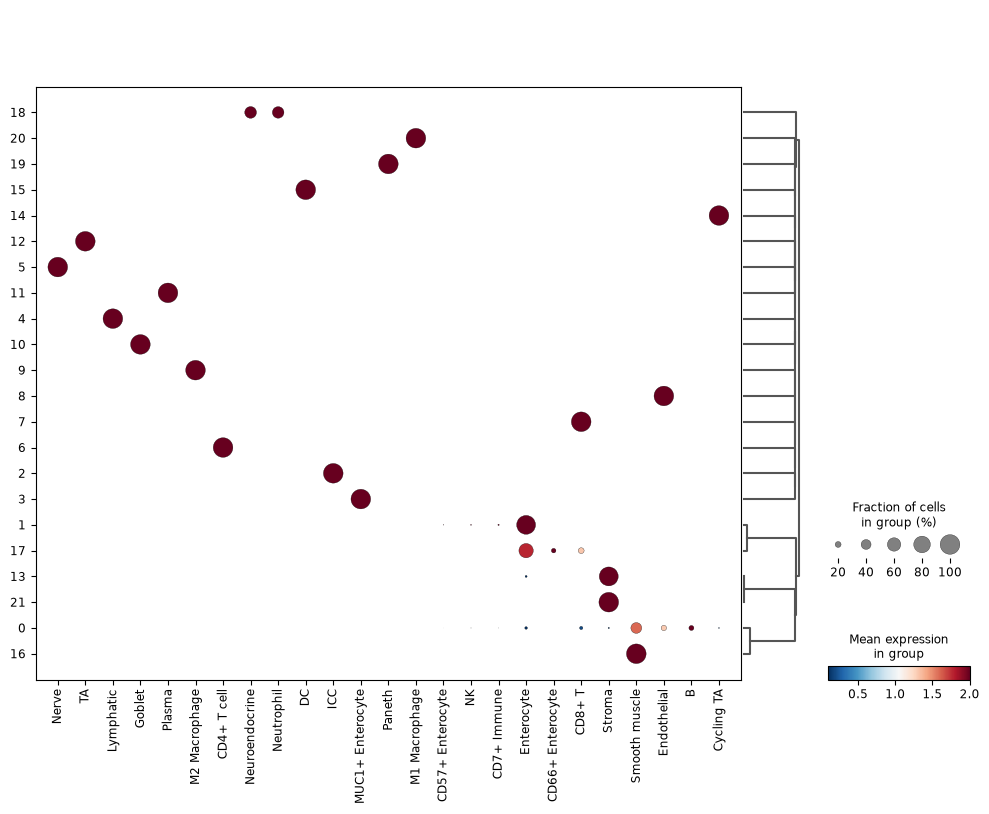

In [68]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list

# Get all cell types
celltype_list = list(cells_mingl.obs["Cell Type"].unique())

# Make each Cell Type a binary variable
celltype_binary = pd.get_dummies(
    cells_mingl.obs["Cell Type"]
)[celltype_list]

# Create AnnData for Cell Type composition
# IMPORTANT: keep X as a dense numeric array so Scanpy dendrogram works
adata_ct = ad.AnnData(
    X=celltype_binary.values.astype(float),
    obs=cells_mingl.obs.copy(),
    var=pd.DataFrame(index=celltype_list)
)

# Calculate proportion of each Cell Type in each Neighborhood
mean_expression = sc.get.obs_df(
    adata_ct,
    keys=celltype_list + ["CC_Neighborhood"]
)

mean_expression_pivot = (
    mean_expression
    .groupby("CC_Neighborhood")
    .mean()
    .T
)

# Calculate overall frequency of each Cell Type
global_frequency = celltype_binary.mean(axis=0)

# Calculate Cell Type enrichment in each Neighborhood
# log2(observed proportion / expected proportion)
enrichment = np.log2(
    (mean_expression_pivot.T + 1e-6) /
    (global_frequency + 1e-6)
)

# Perform hierarchical clustering on the Cell Types
celltype_expression = enrichment.T.values

linkage_matrix = linkage(
    celltype_expression,
    method="ward",
    metric="euclidean"
)

dendro = dendrogram(
    linkage_matrix,
    labels=enrichment.columns,
    no_plot=True
)

ordered_celltypes = [
    enrichment.columns[i]
    for i in leaves_list(linkage_matrix)
]

# Reorder Cell Types in the AnnData object
adata_ct = adata_ct[:, ordered_celltypes]

# Reorder enrichment matrix
enrichment = enrichment[ordered_celltypes]

# Plot
sc.pl.dotplot(
    adata_ct,
    ordered_celltypes,
    groupby="CC_Neighborhood",
    vmax=2,
    vmin=0.1,
    cmap="RdBu_r",
    expression_cutoff=0,
    dendrogram=True,
    swap_axes=False,
    dot_color_df=enrichment,
    save="CellCharter_Neighborhood_CellType_Enrichment.png"
)

In [70]:
composition = pd.crosstab(
    cells_mingl.obs["CC_Neighborhood"],
    cells_mingl.obs["Cell Type"],
    normalize="index"
) * 100

display(composition.round(1))

Cell Type,B,CD4+ T cell,CD57+ Enterocyte,CD66+ Enterocyte,CD7+ Immune,CD8+ T,Cycling TA,DC,Endothelial,Enterocyte,...,MUC1+ Enterocyte,NK,Nerve,Neuroendocrine,Neutrophil,Paneth,Plasma,Smooth muscle,Stroma,TA
CC_Neighborhood,,,,,,,,,,,,,,,,,,,,,
0,16.1,0.0,0.0,0.0,0.2,9.1,1.7,0.0,17.7,6.9,...,0.0,0.4,0.0,0.0,0.0,0.0,0.0,45.1,2.6,0.0
1,0.0,0.0,0.7,0.0,2.7,0.0,0.0,0.0,0.0,94.9,...,0.0,1.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,95.3,0.0
14,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0


In [72]:
dominant_celltype = composition.idxmax(axis=1)
dominant_percent = composition.max(axis=1)

summary = pd.DataFrame({
    "Dominant Cell Type": dominant_celltype,
    "Dominant %": dominant_percent
})

display(summary.sort_values("Dominant %", ascending=False))

,Dominant Cell Type,Dominant %
CC_Neighborhood,,
11,Plasma,100.000000
10,Goblet,100.000000
12,TA,100.000000
16,Smooth muscle,100.000000
15,DC,100.000000
14,Cycling TA,100.000000
6,CD4+ T cell,100.000000
7,CD8+ T,100.000000
4,Lymphatic,100.000000


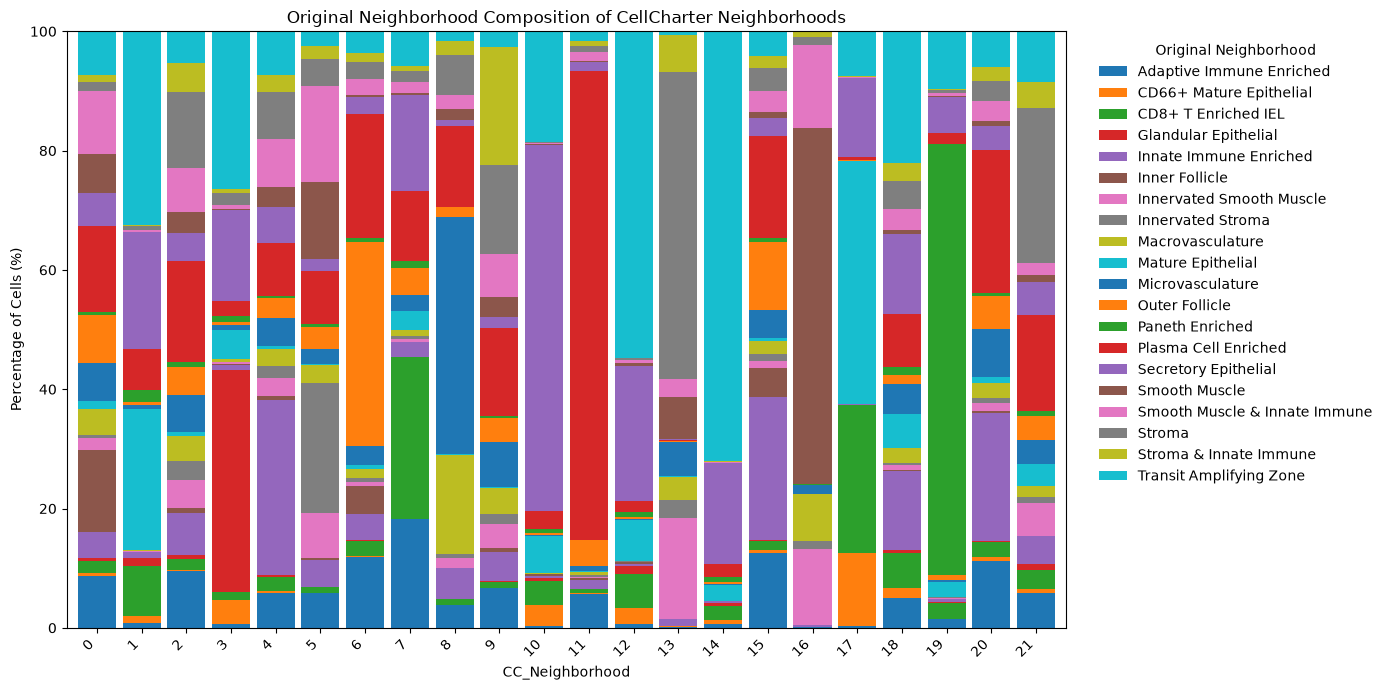

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. Get CC Neighborhood and original Neighborhood labels
# ============================================================

df = cells_mingl.obs[
    ["CC_Neighborhood", "Neighborhood"]
].copy()

df["CC_Neighborhood"] = df["CC_Neighborhood"].astype(str)
df["Neighborhood"] = df["Neighborhood"].astype(str)

# ============================================================
# 2. Count cells from each original Neighborhood
#    within each CC_Neighborhood
# ============================================================

counts = pd.crosstab(
    df["CC_Neighborhood"],
    df["Neighborhood"]
)

# ============================================================
# 3. Convert counts to percentage within each CC_Neighborhood
#    Each row will sum to 100%
# ============================================================

percent = counts.div(
    counts.sum(axis=1),
    axis=0
) * 100

# ============================================================
# 4. Sort CC_Neighborhood labels numerically if possible
# ============================================================

try:
    ordered_cc = sorted(
        percent.index,
        key=lambda x: int(x)
    )
    percent = percent.loc[ordered_cc]
except ValueError:
    percent = percent.sort_index()

# ============================================================
# 5. Plot 100% stacked bar chart
# ============================================================

ax = percent.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    width=0.85
)

ax.set_xlabel("CC_Neighborhood")
ax.set_ylabel("Percentage of Cells (%)")
ax.set_title(
    "Original Neighborhood Composition of CellCharter Neighborhoods"
)

ax.set_ylim(0, 100)

ax.legend(
    title="Original Neighborhood",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

# ============================================================
# 6. Save
# ============================================================

plt.savefig(
    "CC_Neighborhood_Original_Neighborhood_Composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

try not using focal cell in the analysis

In [76]:
import cellcharter as cc
import pandas as pd
from sklearn.metrics import adjusted_rand_score

# ============================================================
# 1. Build CellCharter representation WITHOUT focal cell
#    Uses only 1-hop, 2-hop, and 3-hop neighbors
# ============================================================

cc.gr.aggregate_neighbors(
    adata_full,
    n_layers=[1, 2, 3],
    use_rep="X_pca",
    sample_key="unique_region",
    out_key="X_cellcharter_nofocal"
)

print("No-focal CellCharter representation:")
print(adata_full.obsm["X_cellcharter_nofocal"].shape)


# ============================================================
# 2. Run ONLY K = 20, 21, 22
#    Each result gets a NEW key
# ============================================================

for k in [20, 21, 22]:

    print(f"\nRunning K = {k}")

    model = cc.tl.Cluster(
        n_clusters=k,
        random_state=12345
    )

    model.fit(
        adata_full,
        use_rep="X_cellcharter_nofocal"
    )

    adata_full.obs[f"cc_nofocal_K{k}"] = model.predict(
        adata_full,
        use_rep="X_cellcharter_nofocal"
    )

    print(f"Saved: adata_full.obs['cc_nofocal_K{k}']")


# ============================================================
# 3. Compute pairwise ARI between K = 20, 21, 22
# ============================================================

cluster_keys = [
    "cc_nofocal_K20",
    "cc_nofocal_K21",
    "cc_nofocal_K22"
]

ari_matrix = pd.DataFrame(
    index=cluster_keys,
    columns=cluster_keys,
    dtype=float
)

for key1 in cluster_keys:
    for key2 in cluster_keys:

        ari_matrix.loc[key1, key2] = adjusted_rand_score(
            adata_full.obs[key1],
            adata_full.obs[key2]
        )

print("\nPairwise ARI:")
display(ari_matrix.round(3))

100%|██████████| 64/64 [00:26<00:00,  2.40it/s]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_V

No-focal CellCharter representation:
(2512002, 60)

Running K = 20


`Trainer.fit` stopped: `max_epochs=39` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try install

/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Cholesky decomposition failed. Retrying with covariance regularization 9.999999999999999e-06.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightnin

...

Cholesky decomposition failed. Retrying with covariance regularization 9.999999999999999e-06.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightnin

Cholesky decomposition failed. Retrying with covariance regularization 9.999999999999999e-05.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightnin

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Saved: adata_full.obs['cc_nofocal_K22']

Pairwise ARI:


,cc_nofocal_K20,cc_nofocal_K21,cc_nofocal_K22
cc_nofocal_K20,1.000,0.859,0.592
cc_nofocal_K21,0.859,1.000,0.602
cc_nofocal_K22,0.592,0.602,1.000


In [77]:
# ============================================================
# Select K with highest average pairwise ARI
# ============================================================

ari_no_self = ari_matrix.copy()

for key in ari_no_self.index:
    ari_no_self.loc[key, key] = np.nan

mean_ari = ari_no_self.mean(axis=1)

best_key = mean_ari.idxmax()
best_k = int(best_key.split("K")[-1])

print("Mean ARI:")
print(mean_ari)

print("\nSelected K:", best_k)
print("Selected key:", best_key)

Mean ARI:
cc_nofocal_K20    0.725332
cc_nofocal_K21    0.730612
cc_nofocal_K22    0.596836
dtype: float64

Selected K: 21
Selected key: cc_nofocal_K21


/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/labuser/anaconda3/envs/cellcharter/lib/python3.13/site-packages/anndata/_core/anndata.py:1255: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


/tmp/ipykernel_2432535/663167738.py:66: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


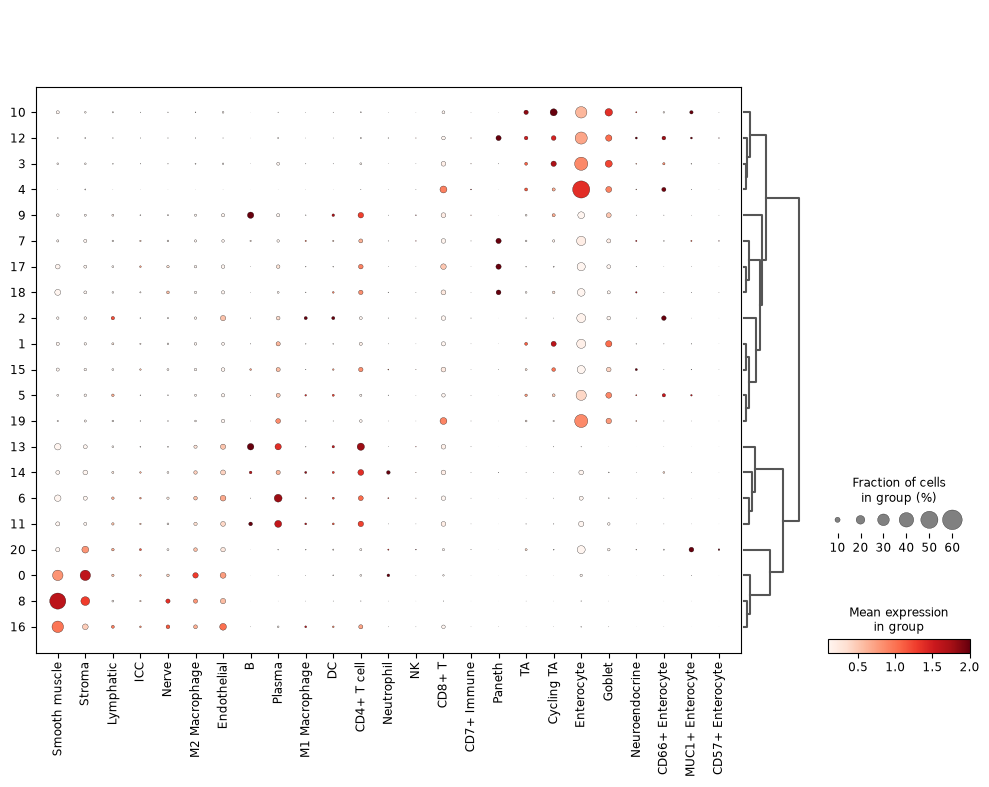

In [80]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list

# ============================================================
# Cell Type enrichment for highest-ARI no-focal solution
# ============================================================

celltype_list = list(adata_full.obs["Cell Type"].astype(str).unique())

# Binary Cell Type matrix
celltype_binary = pd.get_dummies(
    adata_full.obs["Cell Type"].astype(str)
)[celltype_list]

# Create temporary AnnData
adata_ct = ad.AnnData(
    X=celltype_binary.values.astype(float),
    obs=adata_full.obs.copy(),
    var=pd.DataFrame(index=celltype_list)
)

# Make cluster labels categorical
adata_ct.obs[best_key] = adata_ct.obs[best_key].astype("category")

# Calculate proportion of each Cell Type in each cluster
mean_expression = sc.get.obs_df(
    adata_ct,
    keys=celltype_list + [best_key]
)

mean_expression_pivot = (
    mean_expression
    .groupby(best_key, observed=True)
    .mean()
    .T
)

# Overall Cell Type frequency
global_frequency = celltype_binary.mean(axis=0)

# log2 enrichment
enrichment = np.log2(
    (mean_expression_pivot.T + 1e-6) /
    (global_frequency + 1e-6)
)

# Hierarchical clustering of Cell Types
linkage_matrix = linkage(
    enrichment.T.values,
    method="ward",
    metric="euclidean"
)

ordered_celltypes = [
    enrichment.columns[i]
    for i in leaves_list(linkage_matrix)
]

# Reorder
adata_ct = adata_ct[:, ordered_celltypes]
enrichment = enrichment[ordered_celltypes]

# Plot
sc.pl.dotplot(
    adata_ct,
    ordered_celltypes,
    groupby=best_key,
    vmax=2,
    vmin=0.1,
    expression_cutoff=0,
    dendrogram=True,
    swap_axes=False,
    dot_color_df=enrichment,
    save=f"nofocal_K{best_k}_CellType_Enrichment.png"
)

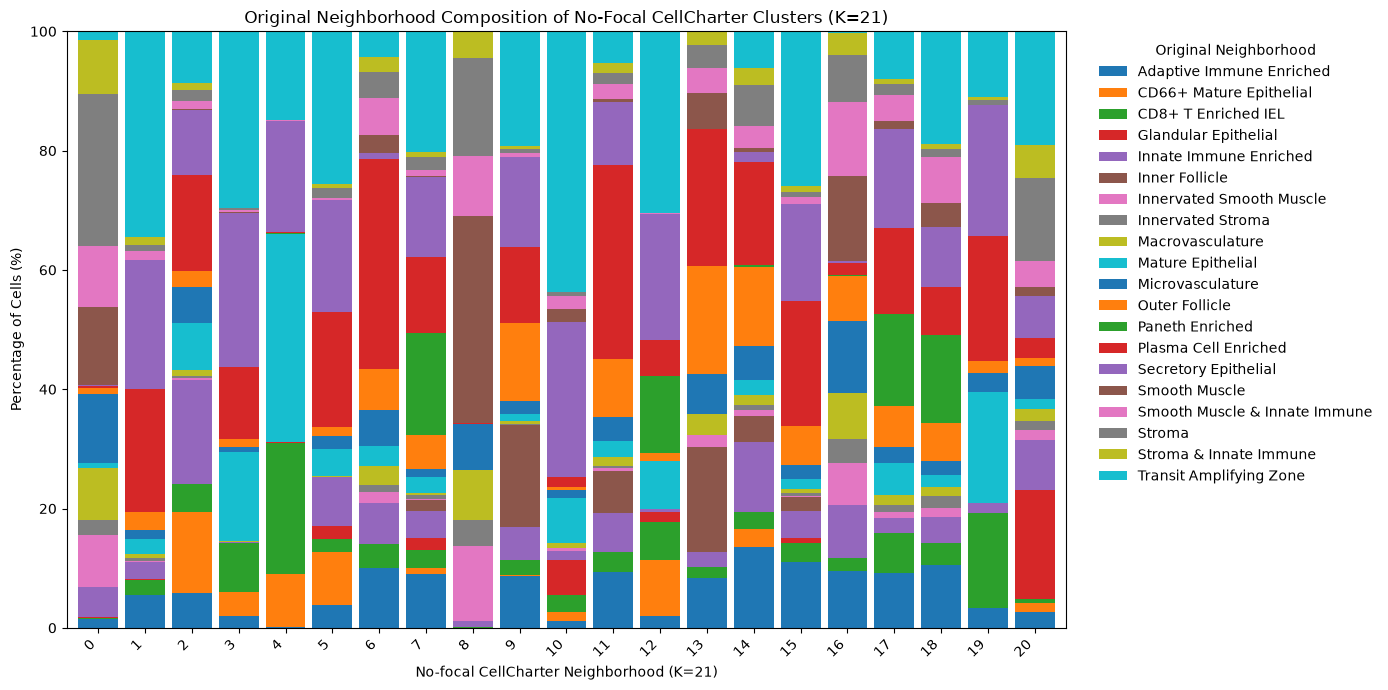

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Original Neighborhood composition of selected no-focal K
# ============================================================

df = adata_full.obs[
    [best_key, "Neighborhood"]
].copy()

df[best_key] = df[best_key].astype(str)
df["Neighborhood"] = df["Neighborhood"].astype(str)

# Count cells
counts = pd.crosstab(
    df[best_key],
    df["Neighborhood"]
)

# Convert to percentage within each CellCharter cluster
percent = counts.div(
    counts.sum(axis=1),
    axis=0
) * 100

# Sort cluster numbers
try:
    percent = percent.loc[
        sorted(percent.index, key=lambda x: int(x))
    ]
except ValueError:
    percent = percent.sort_index()

# Plot
ax = percent.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    width=0.85
)

ax.set_xlabel(f"No-focal CellCharter Neighborhood (K={best_k})")
ax.set_ylabel("Percentage of Cells (%)")
ax.set_title(
    f"Original Neighborhood Composition of No-Focal CellCharter Clusters (K={best_k})"
)

ax.set_ylim(0, 100)

ax.legend(
    title="Original Neighborhood",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    f"nofocal_K{best_k}_Original_Neighborhood_Composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
# ============================================================
# Cell Type composition of selected no-focal solution
# ============================================================

composition = pd.crosstab(
    adata_full.obs[best_key],
    adata_full.obs["Cell Type"],
    normalize="index"
) * 100

display(composition.round(1))

# Dominant Cell Type per cluster
summary = pd.DataFrame({
    "Dominant Cell Type": composition.idxmax(axis=1),
    "Dominant %": composition.max(axis=1)
})

display(summary.round(1))

Cell Type,B,CD4+ T cell,CD7+ Immune,CD8+ T,CD57+ Enterocyte,CD66+ Enterocyte,Cycling TA,DC,Endothelial,Enterocyte,...,MUC1+ Enterocyte,NK,Nerve,Neuroendocrine,Neutrophil,Paneth,Plasma,Smooth muscle,Stroma,TA
cc_nofocal_K21,,,,,,,,,,,,,,,,,,,,,
0,0.0,2.6,0.0,1.9,0.0,0.2,0.0,1.0,12.1,3.8,...,0.3,0.1,4.1,0.0,4.4,0.0,0.2,26.0,25.7,0.1
1,0.4,5.2,0.1,7.8,0.0,0.4,10.2,0.9,4.7,21.5,...,0.5,0.1,2.3,0.7,0.3,0.0,7.8,5.5,3.9,4.9
2,0.4,4.8,0.4,8.4,0.0,8.7,0.2,5.3,10.4,21.1,...,0.1,0.3,1.7,0.3,0.4,0.0,6.6,3.8,4.1,0.6
3,0.1,2.7,0.5,9.0,0.1,3.5,10.8,0.3,2.1,35.3,...,0.9,0.2,0.6,1.1,0.1,0.3,4.7,2.4,2.3,4.8
4,0.0,0.4,1.0,15.1,0.1,7.7,5.3,0.0,0.0,50.0,...,0.4,0.2,0.0,0.9,0.1,0.0,0.0,0.1,1.2,5.0
5,0.3,3.3,0.2,6.4,0.0,5.8,4.6,3.1,5.7,25.3,...,2.1,0.1,1.1,1.4,0.5,0.0,7.3,2.7,4.0,3.9
6,0.4,9.6,0.2,8.4,0.0,0.2,0.3,3.0,11.6,7.2,...,0.0,0.4,3.6,0.1,1.3,0.0,17.6,13.6,7.2,0.1
7,1.7,7.2,0.3,8.6,0.7,1.0,3.7,1.8,4.1,22.0,...,1.5,0.6,2.4,1.7,0.5,10.5,3.9,3.3,5.3,2.4
8,0.0,0.5,0.0,0.4,0.0,0.0,0.0,0.3,10.7,0.6,...,0.0,0.0,7.8,0.0,0.1,0.0,0.0,46.1,20.6,0.1


,Dominant Cell Type,Dominant %
cc_nofocal_K21,,
0,Smooth muscle,26.0
1,Enterocyte,21.5
2,Enterocyte,21.1
3,Enterocyte,35.3
4,Enterocyte,50.0
5,Enterocyte,25.3
6,Plasma,17.6
7,Enterocyte,22.0
8,Smooth muscle,46.1


In [84]:
import numpy as np
import pandas as pd

cluster_key = "cc_nofocal_K21"

# ============================================================
# 1. ORIGINAL "Neighborhood" enrichment
# ============================================================

neigh_counts = pd.crosstab(
    adata_full.obs[cluster_key],
    adata_full.obs["Neighborhood"]
)

neigh_fraction = neigh_counts.div(
    neigh_counts.sum(axis=1),
    axis=0
)

neigh_global = (
    neigh_counts.sum(axis=0) /
    neigh_counts.values.sum()
)

neigh_enrichment = np.log2(
    (neigh_fraction + 1e-6) /
    (neigh_global + 1e-6)
)


# ============================================================
# 2. CELL TYPE enrichment
# ============================================================

ct_counts = pd.crosstab(
    adata_full.obs[cluster_key],
    adata_full.obs["Cell Type"]
)

ct_fraction = ct_counts.div(
    ct_counts.sum(axis=1),
    axis=0
)

ct_global = (
    ct_counts.sum(axis=0) /
    ct_counts.values.sum()
)

ct_enrichment = np.log2(
    (ct_fraction + 1e-6) /
    (ct_global + 1e-6)
)


# ============================================================
# 3. Extract strongest meaningful enrichments
#
# Only consider populations making up >= 5% of the cluster
# so extremely rare populations don't drive the label.
# ============================================================

rows = []

for cluster in neigh_enrichment.index:

    # ---------- Original Neighborhoods ----------
    valid_neigh = neigh_fraction.loc[cluster] >= 0.05

    neigh_rank = (
        neigh_enrichment.loc[cluster][valid_neigh]
        .sort_values(ascending=False)
    )

    top_neigh = neigh_rank.index[:2].tolist()

    # ---------- Cell Types ----------
    valid_ct = ct_fraction.loc[cluster] >= 0.05

    ct_rank = (
        ct_enrichment.loc[cluster][valid_ct]
        .sort_values(ascending=False)
    )

    top_ct = ct_rank.index[:2].tolist()

    row = {
        "CC": cluster
    }

    # Top original Neighborhood
    for i in range(2):
        if i < len(top_neigh):
            n = top_neigh[i]

            row[f"Neighborhood_{i+1}"] = n
            row[f"Neighborhood_{i+1}_pct"] = round(
                neigh_fraction.loc[cluster, n] * 100, 1
            )
            row[f"Neighborhood_{i+1}_log2FC"] = round(
                neigh_enrichment.loc[cluster, n], 2
            )

    # Top Cell Type
    for i in range(2):
        if i < len(top_ct):
            ct = top_ct[i]

            row[f"CellType_{i+1}"] = ct
            row[f"CellType_{i+1}_pct"] = round(
                ct_fraction.loc[cluster, ct] * 100, 1
            )
            row[f"CellType_{i+1}_log2FC"] = round(
                ct_enrichment.loc[cluster, ct], 2
            )

    rows.append(row)


# ============================================================
# 4. Summary table
# ============================================================

label_summary = pd.DataFrame(rows).set_index("CC")

display(label_summary)

,Neighborhood_1,Neighborhood_1_pct,Neighborhood_1_log2FC,Neighborhood_2,Neighborhood_2_pct,Neighborhood_2_log2FC,CellType_1,CellType_1_pct,CellType_1_log2FC,CellType_2,CellType_2_pct,CellType_2_log2FC
CC,,,,,,,,,,,,
0,Stroma,25.5,2.10,Stroma & Innate Immune,9.1,2.09,Stroma,25.7,1.60,M2 Macrophage,11.0,1.29
1,Transit Amplifying Zone,34.5,1.57,Secretory Epithelial,21.6,0.95,Cycling TA,10.2,1.62,Goblet,13.3,1.03
2,CD66+ Mature Epithelial,13.6,2.59,Innate Immune Enriched,17.4,2.39,M1 Macrophage,5.2,2.59,CD66+ Enterocyte,8.7,2.15
3,Transit Amplifying Zone,29.5,1.35,Secretory Epithelial,25.9,1.21,Cycling TA,10.8,1.71,Goblet,15.3,1.24
4,CD66+ Mature Epithelial,8.9,1.97,Mature Epithelial,35.0,1.93,CD66+ Enterocyte,7.7,1.96,Enterocyte,50.0,1.37
5,CD66+ Mature Epithelial,9.0,1.99,Innate Immune Enriched,8.1,1.30,CD66+ Enterocyte,5.8,1.55,Goblet,12.0,0.89
6,Plasma Cell Enriched,35.2,1.67,Adaptive Immune Enriched,10.0,1.28,Plasma,17.6,1.79,CD4+ T cell,9.6,1.04
7,Paneth Enriched,17.1,3.86,Adaptive Immune Enriched,8.9,1.13,Paneth,10.5,3.63,CD4+ T cell,7.2,0.63
8,Smooth Muscle,34.7,2.04,Innervated Smooth Muscle,12.5,1.86,Smooth muscle,46.1,1.63,Nerve,7.8,1.36


In [85]:
# ============================================================
# 1. Copy no-focal K21 clusters into adata_full
#    Keep the original numeric cluster IDs
# ============================================================

adata_full.obs["cc_nofocal_K21"] = (
    adata_full.obs["cc_nofocal_K21"]
    .reindex(adata_full.obs_names)
)

# Make sure all cells matched correctly
print("Missing cluster labels:", adata_full.obs["cc_nofocal_K21"].isna().sum())


# ============================================================
# 2. Define neighborhood labels
# ============================================================

cc_nofocal_K21_labels = {
    "0":  "Stroma",
    "1":  "Transit Amplifying Zone",
    "2":  "CD66+ Mature Epithelial",
    "3":  "Secretory Epithelial",
    "4":  "Mature Epithelial",
    "5":  "CD66+ Secretory Epithelial",
    "6":  "Plasma Cell Enriched",
    "7":  "Paneth Enriched",
    "8":  "Innervated Smooth Muscle",
    "9":  "Inner Follicle",
    "10": "Proliferative Glandular Epithelial",
    "11": "Outer Follicle",
    "12": "Paneth Enriched Mature Epithelial",
    "13": "Outer Follicle",
    "14": "Outer Follicle",
    "15": "Adaptive Immune Enriched",
    "16": "Smooth Muscle & Innate Immune",
    "17": "Paneth Enriched",
    "18": "Paneth Enriched",
    "19": "CD8+ T Enriched IEL",
    "20": "Glandular Epithelial"
}


# ============================================================
# 3. Create labeled neighborhood column
# ============================================================

adata_full.obs["CC_Neighborhood_Label"] = (
    adata_full.obs["cc_nofocal_K21"]
    .astype(str)
    .map(cc_nofocal_K21_labels)
    .astype("category")
)


# ============================================================
# 4. Confirm assignments
# ============================================================

print(
    adata_full.obs[
        ["cc_nofocal_K21", "CC_Neighborhood_Label"]
    ]
    .drop_duplicates()
    .sort_values("cc_nofocal_K21")
    .to_string(index=False)
)


# ============================================================
# 5. Save updated AnnData
# ============================================================

adata_full.write_h5ad(
    "adata_full_cellcharter_nofocal_K21_labeled.h5ad"
)

print("\nSaved:")
print("adata_full_cellcharter_nofocal_K21_labeled.h5ad")

Missing cluster labels: 0
cc_nofocal_K21              CC_Neighborhood_Label
             0                             Stroma
             1            Transit Amplifying Zone
             2            CD66+ Mature Epithelial
             3               Secretory Epithelial
             4                  Mature Epithelial
             5         CD66+ Secretory Epithelial
             6               Plasma Cell Enriched
             7                    Paneth Enriched
             8           Innervated Smooth Muscle
             9                     Inner Follicle
            10 Proliferative Glandular Epithelial
            11                     Outer Follicle
            12  Paneth Enriched Mature Epithelial
            13                     Outer Follicle
            14                     Outer Follicle
            15           Adaptive Immune Enriched
            16      Smooth Muscle & Innate Immune
            17                    Paneth Enriched
            18          

MINGL

In [3]:
# load data
file_path =r"Z:\MINGLE\Reviewer Response\Raina\Code\R2.4\adata_full_cellcharter_nofocal_K21_labeled_network.h5ad"
cells = mg.pp.read_file(file_path)

In [22]:
# MINGL centroid_Calculation does not handle pandas Categorical labels well
# Convert annotation columns to regular strings

cells_mingl.obs["Cell Type"] = cells_mingl.obs["Cell Type"].astype(str)

# If you are using the new CellCharter neighborhood labels:
if "CC_Neighborhood_Label_Updated" in cells.obs.columns:
    cells_mingl.obs["CC_Neighborhood_Label_Updated"] = cells_mingl.obs["CC_Neighborhood_Label_Updated"].astype(str)

# Region column as string as well
if "unique_region" in cells_mingl.obs.columns:
    cells_mingl.obs["unique_region"] = cells_mingl.obs["unique_region"].astype(str)

print(cells_mingl.obs["Cell Type"].dtype)
print(cells_mingl.obs["Cell Type"].unique())

object
['NK' 'Enterocyte' 'MUC1+ Enterocyte' 'TA' 'CD66+ Enterocyte' 'Paneth'
 'Smooth muscle' 'M1 Macrophage' 'Goblet' 'Neuroendocrine'
 'CD57+ Enterocyte' 'Lymphatic' 'CD8+ T' 'DC' 'M2 Macrophage' 'B'
 'Neutrophil' 'Endothelial' 'Cycling TA' 'Plasma' 'CD4+ T cell' 'Stroma'
 'Nerve' 'ICC' 'CD7+ Immune']


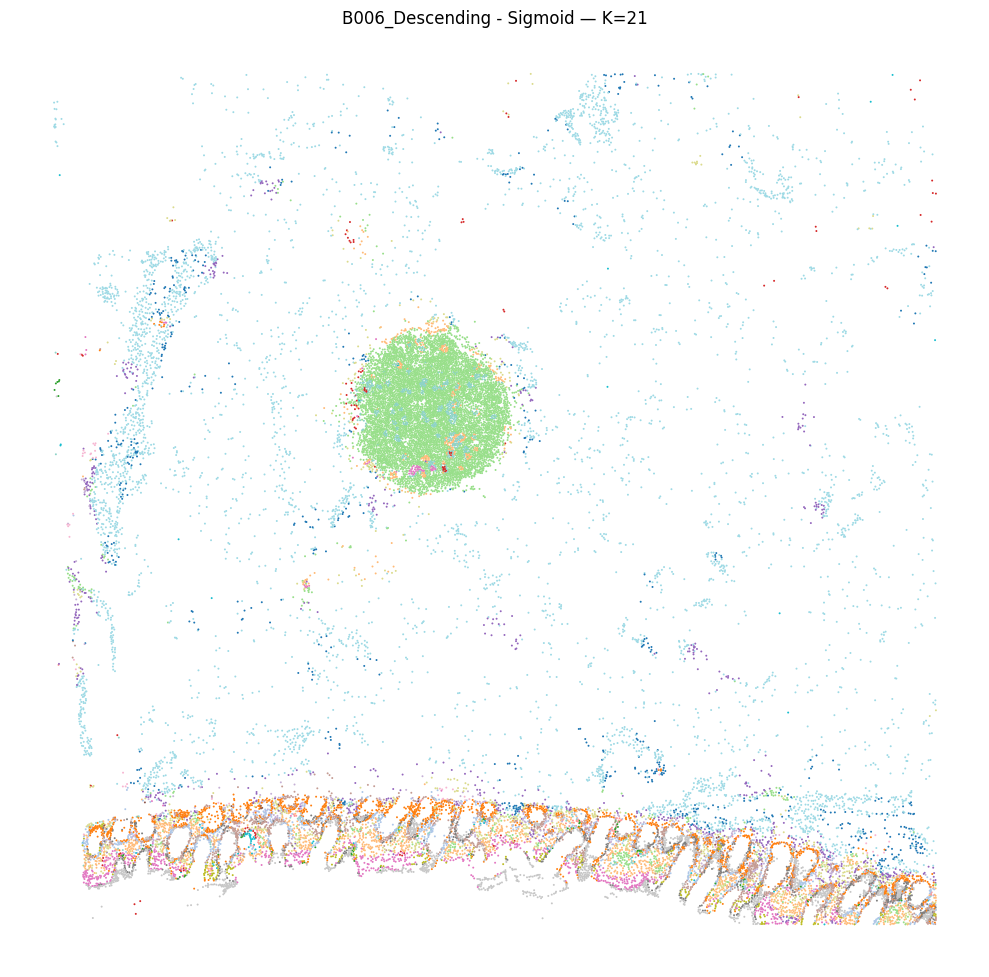

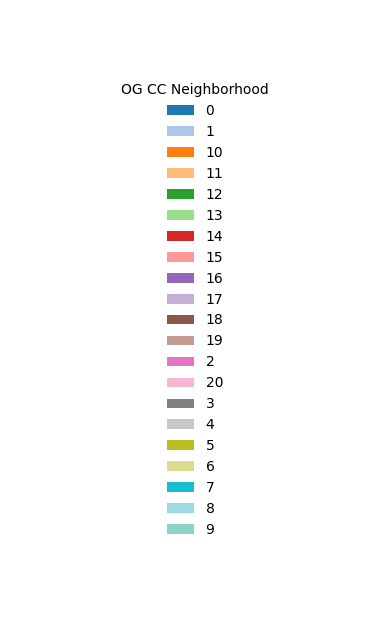

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

region = "B006_Descending - Sigmoid"

mask = cells_mingl.obs["unique_region"].eq(region).to_numpy()

coords = np.asarray(cells_mingl.obsm["spatial"])[mask]

labels = cells_mingl.obs.loc[
    mask, "cc_nofocal_K21"
].astype(str)

# SAME palette used for the network nodes
neighborhood_color_map = {
    str(label): color
    for label, color in og_CC_neigh_dict.items()
}

all_neighborhoods = sorted(neighborhood_color_map)
n_neighborhoods = len(all_neighborhoods)

point_colors = [
    neighborhood_color_map[label]
    for label in labels
]

# Plot spatial neighborhoods
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=point_colors,
    s=2,
    linewidths=0,
    rasterized=True,
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title(f"{region} — K={n_neighborhoods}")
ax.axis("off")

plt.tight_layout()
plt.show()

# Separate legend figure, using the same palette
legend_handles = [
    Patch(
        facecolor=neighborhood_color_map[neighborhood],
        edgecolor="none",
        label=neighborhood,
    )
    for neighborhood in all_neighborhoods
]

legend_fig, legend_ax = plt.subplots(
    figsize=(4, max(3, n_neighborhoods * 0.3))
)

legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    title="OG CC Neighborhood",
    loc="center",
    frameon=False,
)

plt.tight_layout()
plt.show()

change cc_nofocal_k21 cluster 11 to be plasma cell enriched instead

In [15]:
# ============================================================
# 1. Copy no-focal K21 clusters into adata_full
#    Keep the original numeric cluster IDs
# ============================================================

cells_mingl.obs["cc_nofocal_K21"] = (
    cells_mingl.obs["cc_nofocal_K21"]
    .reindex(cells_mingl.obs_names)
)

# Make sure all cells matched correctly
print("Missing cluster labels:", cells_mingl.obs["cc_nofocal_K21"].isna().sum())


# ============================================================
# 2. Define neighborhood labels
# ============================================================

cc_nofocal_K21_labels = {
    "0":  "Stroma",
    "1":  "Transit Amplifying Zone",
    "2":  "CD66+ Mature Epithelial",
    "3":  "Secretory Epithelial",
    "4":  "Mature Epithelial",
    "5":  "CD66+ Secretory Epithelial",
    "6":  "Plasma Cell Enriched",
    "7":  "Paneth Enriched",
    "8":  "Innervated Smooth Muscle",
    "9":  "Inner Follicle",
    "10": "Proliferative Glandular Epithelial",
    "11": "Plasma Cell Enriched",
    "12": "Paneth Enriched Mature Epithelial",
    "13": "Outer Follicle",
    "14": "Outer Follicle",
    "15": "Adaptive Immune Enriched",
    "16": "Smooth Muscle & Innate Immune",
    "17": "Paneth Enriched",
    "18": "Paneth Enriched",
    "19": "CD8+ T Enriched IEL",
    "20": "Glandular Epithelial"
}


# ============================================================
# 3. Create labeled neighborhood column
# ============================================================

cells_mingl.obs["CC_Neighborhood_Label_Updated"] = (
    cells_mingl.obs["cc_nofocal_K21"]
    .astype(str)
    .map(cc_nofocal_K21_labels)
    .astype("category")
)


# ============================================================
# 4. Confirm assignments
# ============================================================

print(
    cells_mingl.obs[
        ["cc_nofocal_K21", "CC_Neighborhood_Label_Updated"]
    ]
    .drop_duplicates()
    .sort_values("cc_nofocal_K21")
    .to_string(index=False)
)


# ============================================================
# 5. Save updated AnnData
# ============================================================

cells_mingl.write_h5ad(
    "adata_full_cellcharter_nofocal_K21_labeled_updated.h5ad"
)

print("\nSaved:")
print("adata_full_cellcharter_nofocal_K21_labeled_updated.h5ad")

Missing cluster labels: 0
cc_nofocal_K21      CC_Neighborhood_Label_Updated
             0                             Stroma
             1            Transit Amplifying Zone
             2            CD66+ Mature Epithelial
             3               Secretory Epithelial
             4                  Mature Epithelial
             5         CD66+ Secretory Epithelial
             6               Plasma Cell Enriched
             7                    Paneth Enriched
             8           Innervated Smooth Muscle
             9                     Inner Follicle
            10 Proliferative Glandular Epithelial
            11               Plasma Cell Enriched
            12  Paneth Enriched Mature Epithelial
            13                     Outer Follicle
            14                     Outer Follicle
            15           Adaptive Immune Enriched
            16      Smooth Muscle & Innate Immune
            17                    Paneth Enriched
            18          

In [17]:
print(cells_mingl.obs["CC_Neighborhood_Label_Updated"].unique())

['Plasma Cell Enriched', 'Proliferative Glandular Epithelial', 'Outer Follicle', 'Mature Epithelial', 'Adaptive Immune Enriched', ..., 'CD66+ Secretory Epithelial', 'CD8+ T Enriched IEL', 'Paneth Enriched Mature Epithelial', 'Inner Follicle', 'Innervated Smooth Muscle']
Length: 17
Categories (17, object): ['Adaptive Immune Enriched', 'CD66+ Mature Epithelial', 'CD66+ Secretory Epithelial', 'CD8+ T Enriched IEL', ..., 'Secretory Epithelial', 'Smooth Muscle & Innate Immune', 'Stroma', 'Transit Amplifying Zone']


In [23]:
import mingl as mg

k = 10

centroids_adata = mg.tl.centroids.centroid_Calculation(
    cells_mingl,
    k=k,
    cluster_col="Cell Type",
    neighborhood_col="CC_Neighborhood_Label_Updated",
    region_col="unique_region",
    store_key="cellcharter_centroids_updated"
)

print(centroids_adata)

Example dummy cols: ['Cell Type__B', 'Cell Type__CD4+ T cell', 'Cell Type__CD57+ Enterocyte', 'Cell Type__CD66+ Enterocyte', 'Cell Type__CD7+ Immune']
{5:               x       y   unique_region         Cell Type    B  CD4+ T cell  \
0        3984.0  3387.0  B004_Ascending                NK  0.0          0.0   
1        5188.0  4116.0  B004_Ascending                NK  0.0          0.0   
2        6070.0  3146.0  B004_Ascending                NK  0.0          0.0   
3        6792.0  3891.0  B004_Ascending                NK  0.0          2.0   
4        7968.0  6351.0  B004_Ascending                NK  1.0          3.0   
...         ...     ...             ...               ...  ...          ...   
2511997  7633.0   353.0      B008_Trans                DC  0.0          0.0   
2511998  4921.0   533.0      B008_Trans                DC  0.0          0.0   
2511999  3710.0  6049.0      B008_Trans                DC  0.0          0.0   
2512000  5823.0   794.0      B008_Trans                

In [26]:
cells_mingl = mg.tl.gmm.cpu_gmm_probability(
    cells_mingl,
    centroids_adata,
    cluster_col="Cell Type",
    neighborhood_col="CC_Neighborhood_Label_Updated",
    region_key="unique_region",
    ks=[10,20,100],
    k=k,
    threshold=0.25,
    num_processes=16,
    prob_key="cellcharter_neighborhood_probabilities_updated",
    prob_variable_key="cellcharter_neighborhood_probability_neighborhoods_updated"
)

Example dummy cols: ['Cell Type__B', 'Cell Type__CD4+ T cell', 'Cell Type__CD57+ Enterocyte', 'Cell Type__CD66+ Enterocyte', 'Cell Type__CD7+ Immune']


In [27]:
cells_mingl

AnnData object with n_obs × n_vars = 2512002 × 25
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit', 'cc_K21', 'cc_K22', 'cc_K23', 'cellcharter_clusters', 'spatial_cluster', 'cc_nofocal_K20', 'cc_nofocal_K21', 'cc_nof

In [ ]:
# cells_mingl = cells.copy()

In [28]:
import numpy as np

# Get probability matrix
probability_matrix = cells_mingl.obsm[
    "cellcharter_neighborhood_probabilities_updated"
]

# Get the corresponding labeled neighborhood names
neighborhood_names = [
    str(x)
    for x in cells_mingl.uns[
        "cellcharter_neighborhood_probability_neighborhoods_updated"
    ]
]

print("Neighborhood names:")
print(neighborhood_names)

print("\nNumber of probability columns:", probability_matrix.shape[1])
print("Number of neighborhood names:", len(neighborhood_names))

# Make sure they match
assert len(neighborhood_names) == probability_matrix.shape[1]

# Store each probability using the ACTUAL neighborhood label
for i, name in enumerate(neighborhood_names):
    cells_mingl.obs[name] = probability_matrix[:, i].astype(np.float32)

# These are now the labeled probability columns
prob_cols = neighborhood_names

print("\nProbability columns:")
print(prob_cols)

print(cells_mingl.obs[prob_cols].head())

Neighborhood names:
['Plasma Cell Enriched', 'Proliferative Glandular Epithelial', 'Outer Follicle', 'Mature Epithelial', 'Adaptive Immune Enriched', 'Secretory Epithelial', 'Transit Amplifying Zone', 'Glandular Epithelial', 'CD66+ Mature Epithelial', 'Paneth Enriched', 'Stroma', 'Smooth Muscle & Innate Immune', 'CD66+ Secretory Epithelial', 'CD8+ T Enriched IEL', 'Paneth Enriched Mature Epithelial', 'Inner Follicle', 'Innervated Smooth Muscle']

Number of probability columns: 17
Number of neighborhood names: 17

Probability columns:
['Plasma Cell Enriched', 'Proliferative Glandular Epithelial', 'Outer Follicle', 'Mature Epithelial', 'Adaptive Immune Enriched', 'Secretory Epithelial', 'Transit Amplifying Zone', 'Glandular Epithelial', 'CD66+ Mature Epithelial', 'Paneth Enriched', 'Stroma', 'Smooth Muscle & Innate Immune', 'CD66+ Secretory Epithelial', 'CD8+ T Enriched IEL', 'Paneth Enriched Mature Epithelial', 'Inner Follicle', 'Innervated Smooth Muscle']
   Plasma Cell Enriched  Proli

In [29]:
cells_mingl = mg.tl.edges.findPositives(
    cells_mingl,
    prob_key="cellcharter_neighborhood_probabilities_updated",
    threshold=0.25,
    result_key="Count_Above_Threshold_Updated"
)

print(
    cells_mingl.obs["Count_Above_Threshold_Updated"]
    .value_counts()
    .sort_index()
)

Count_Above_Threshold_Updated
0          9
1    2324594
2     184554
3       2845
Name: count, dtype: int64


In [30]:
G, top_pairs = (
    mg.tl.network_graphs.build_neighborhood_pair_graph(
        cells_mingl,
        prob_cols=prob_cols,
        threshold=0.25,
        region_key="unique_region",
        top_n=35,
        count_key="Count_Above_Threshold_Updated",
        uns_key="cellcharter_neighborhood_pair_graph_updated",
        display_sep=" ⟷ ",
    )
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print(top_pairs.head())

Number of nodes: 16
Number of edges: 35
                        Neighborhood1                  Neighborhood2  count  \
0                              Stroma  Smooth Muscle & Innate Immune  26243   
1                Plasma Cell Enriched                 Outer Follicle  22956   
2                   Mature Epithelial            CD8+ T Enriched IEL  15241   
3             Transit Amplifying Zone            CD8+ T Enriched IEL   9937   
4  Proliferative Glandular Epithelial        Transit Amplifying Zone   9316   

                                   Neighborhood Pair  
0             Stroma ⟷ Smooth Muscle & Innate Immune  
1              Plasma Cell Enriched ⟷ Outer Follicle  
2            Mature Epithelial ⟷ CD8+ T Enriched IEL  
3      Transit Amplifying Zone ⟷ CD8+ T Enriched IEL  
4  Proliferative Glandular Epithelial ⟷ Transit A...  


In [5]:
def make_celltype_palette_strict(df, cell_type_col='Cell_Type'):
    """
    Create a long, non-repeating categorical color palette for each unique cell type.
    Uses a combination of seaborn/matplotlib categorical palettes.
    """
    import seaborn as sns

    # Get unique cell types
    cell_types = sorted(df[cell_type_col].dropna().unique())
    n = len(cell_types)

    # Combine multiple qualitative palettes
    palette_names = ['tab20', 'Set3', 'Set2', 'Paired', 'Dark2', 'Accent']
    combined_colors = []

    for name in palette_names:
        combined_colors.extend(sns.color_palette(name))

    if len(combined_colors) < n:
        raise ValueError(f"Not enough distinct colors for {n} cell types. Max supported is {len(combined_colors)}.")

    # Slice and assign
    final_palette = combined_colors[:n]
    color_dict = dict(zip(cell_types, final_palette))
    return color_dict, final_palette, cell_types

In [75]:
cells_mingl.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 2512002 × 25
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit', 'cc_K21', 'cc_K22', 'cc_K23', 'cellcharter_clusters', 'spatial_cluster', 'cc_nofoc

In [25]:
# Create the palette once
color_dict, color_list, cell_type_list = make_celltype_palette_strict(cells_mingl.obs, cell_type_col='Cell Type')

# Print or check mapping
print(color_dict)

{'B': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'CD4+ T cell': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274), 'CD57+ Enterocyte': (1.0, 0.4980392156862745, 0.054901960784313725), 'CD66+ Enterocyte': (1.0, 0.7333333333333333, 0.47058823529411764), 'CD7+ Immune': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'CD8+ T': (0.596078431372549, 0.8745098039215686, 0.5411764705882353), 'Cycling TA': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), 'DC': (1.0, 0.596078431372549, 0.5882352941176471), 'Endothelial': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'Enterocyte': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589), 'Goblet': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), 'ICC': (0.7686274509803922, 0.611764705882353, 0.5803921568627451), 'Lymphatic': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), 'M1 Macrophage': (0.9686274509803922, 0.7137254901960784, 0.823529411

In [33]:
# Create the palette once
CC_neigh_dict, CC_color_list, CC_cell_type_list = make_celltype_palette_strict(cells_mingl.obs, cell_type_col='CC_Neighborhood_Label_Updated')

# Print or check mapping
print(CC_neigh_dict)

{'Adaptive Immune Enriched': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'CD66+ Mature Epithelial': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274), 'CD66+ Secretory Epithelial': (1.0, 0.4980392156862745, 0.054901960784313725), 'CD8+ T Enriched IEL': (1.0, 0.7333333333333333, 0.47058823529411764), 'Glandular Epithelial': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'Inner Follicle': (0.596078431372549, 0.8745098039215686, 0.5411764705882353), 'Innervated Smooth Muscle': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), 'Mature Epithelial': (1.0, 0.596078431372549, 0.5882352941176471), 'Outer Follicle': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'Paneth Enriched': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589), 'Paneth Enriched Mature Epithelial': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), 'Plasma Cell Enriched': (0.7686274509803922, 0.611764705882353, 0.5803921568627451)

In [10]:
cells_mingl.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 2512002 × 25
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit', 'cc_K21', 'cc_K22', 'cc_K23', 'cellcharter_clusters', 'spatial_cluster', 'cc_nofoc

In [11]:
# Create the palette once
og_CC_neigh_dict, og_CC_color_list, og_CC_cell_type_list = make_celltype_palette_strict(cells_mingl.obs, cell_type_col='cc_nofocal_K21')

# Print or check mapping
print(og_CC_neigh_dict)

{'0': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), '1': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274), '10': (1.0, 0.4980392156862745, 0.054901960784313725), '11': (1.0, 0.7333333333333333, 0.47058823529411764), '12': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), '13': (0.596078431372549, 0.8745098039215686, 0.5411764705882353), '14': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), '15': (1.0, 0.596078431372549, 0.5882352941176471), '16': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), '17': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589), '18': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), '19': (0.7686274509803922, 0.611764705882353, 0.5803921568627451), '2': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), '20': (0.9686274509803922, 0.7137254901960784, 0.8235294117647058), '3': (0.4980392156862745, 0.4980392156862745, 0.4980392156862745), '4': (0.780392156862745

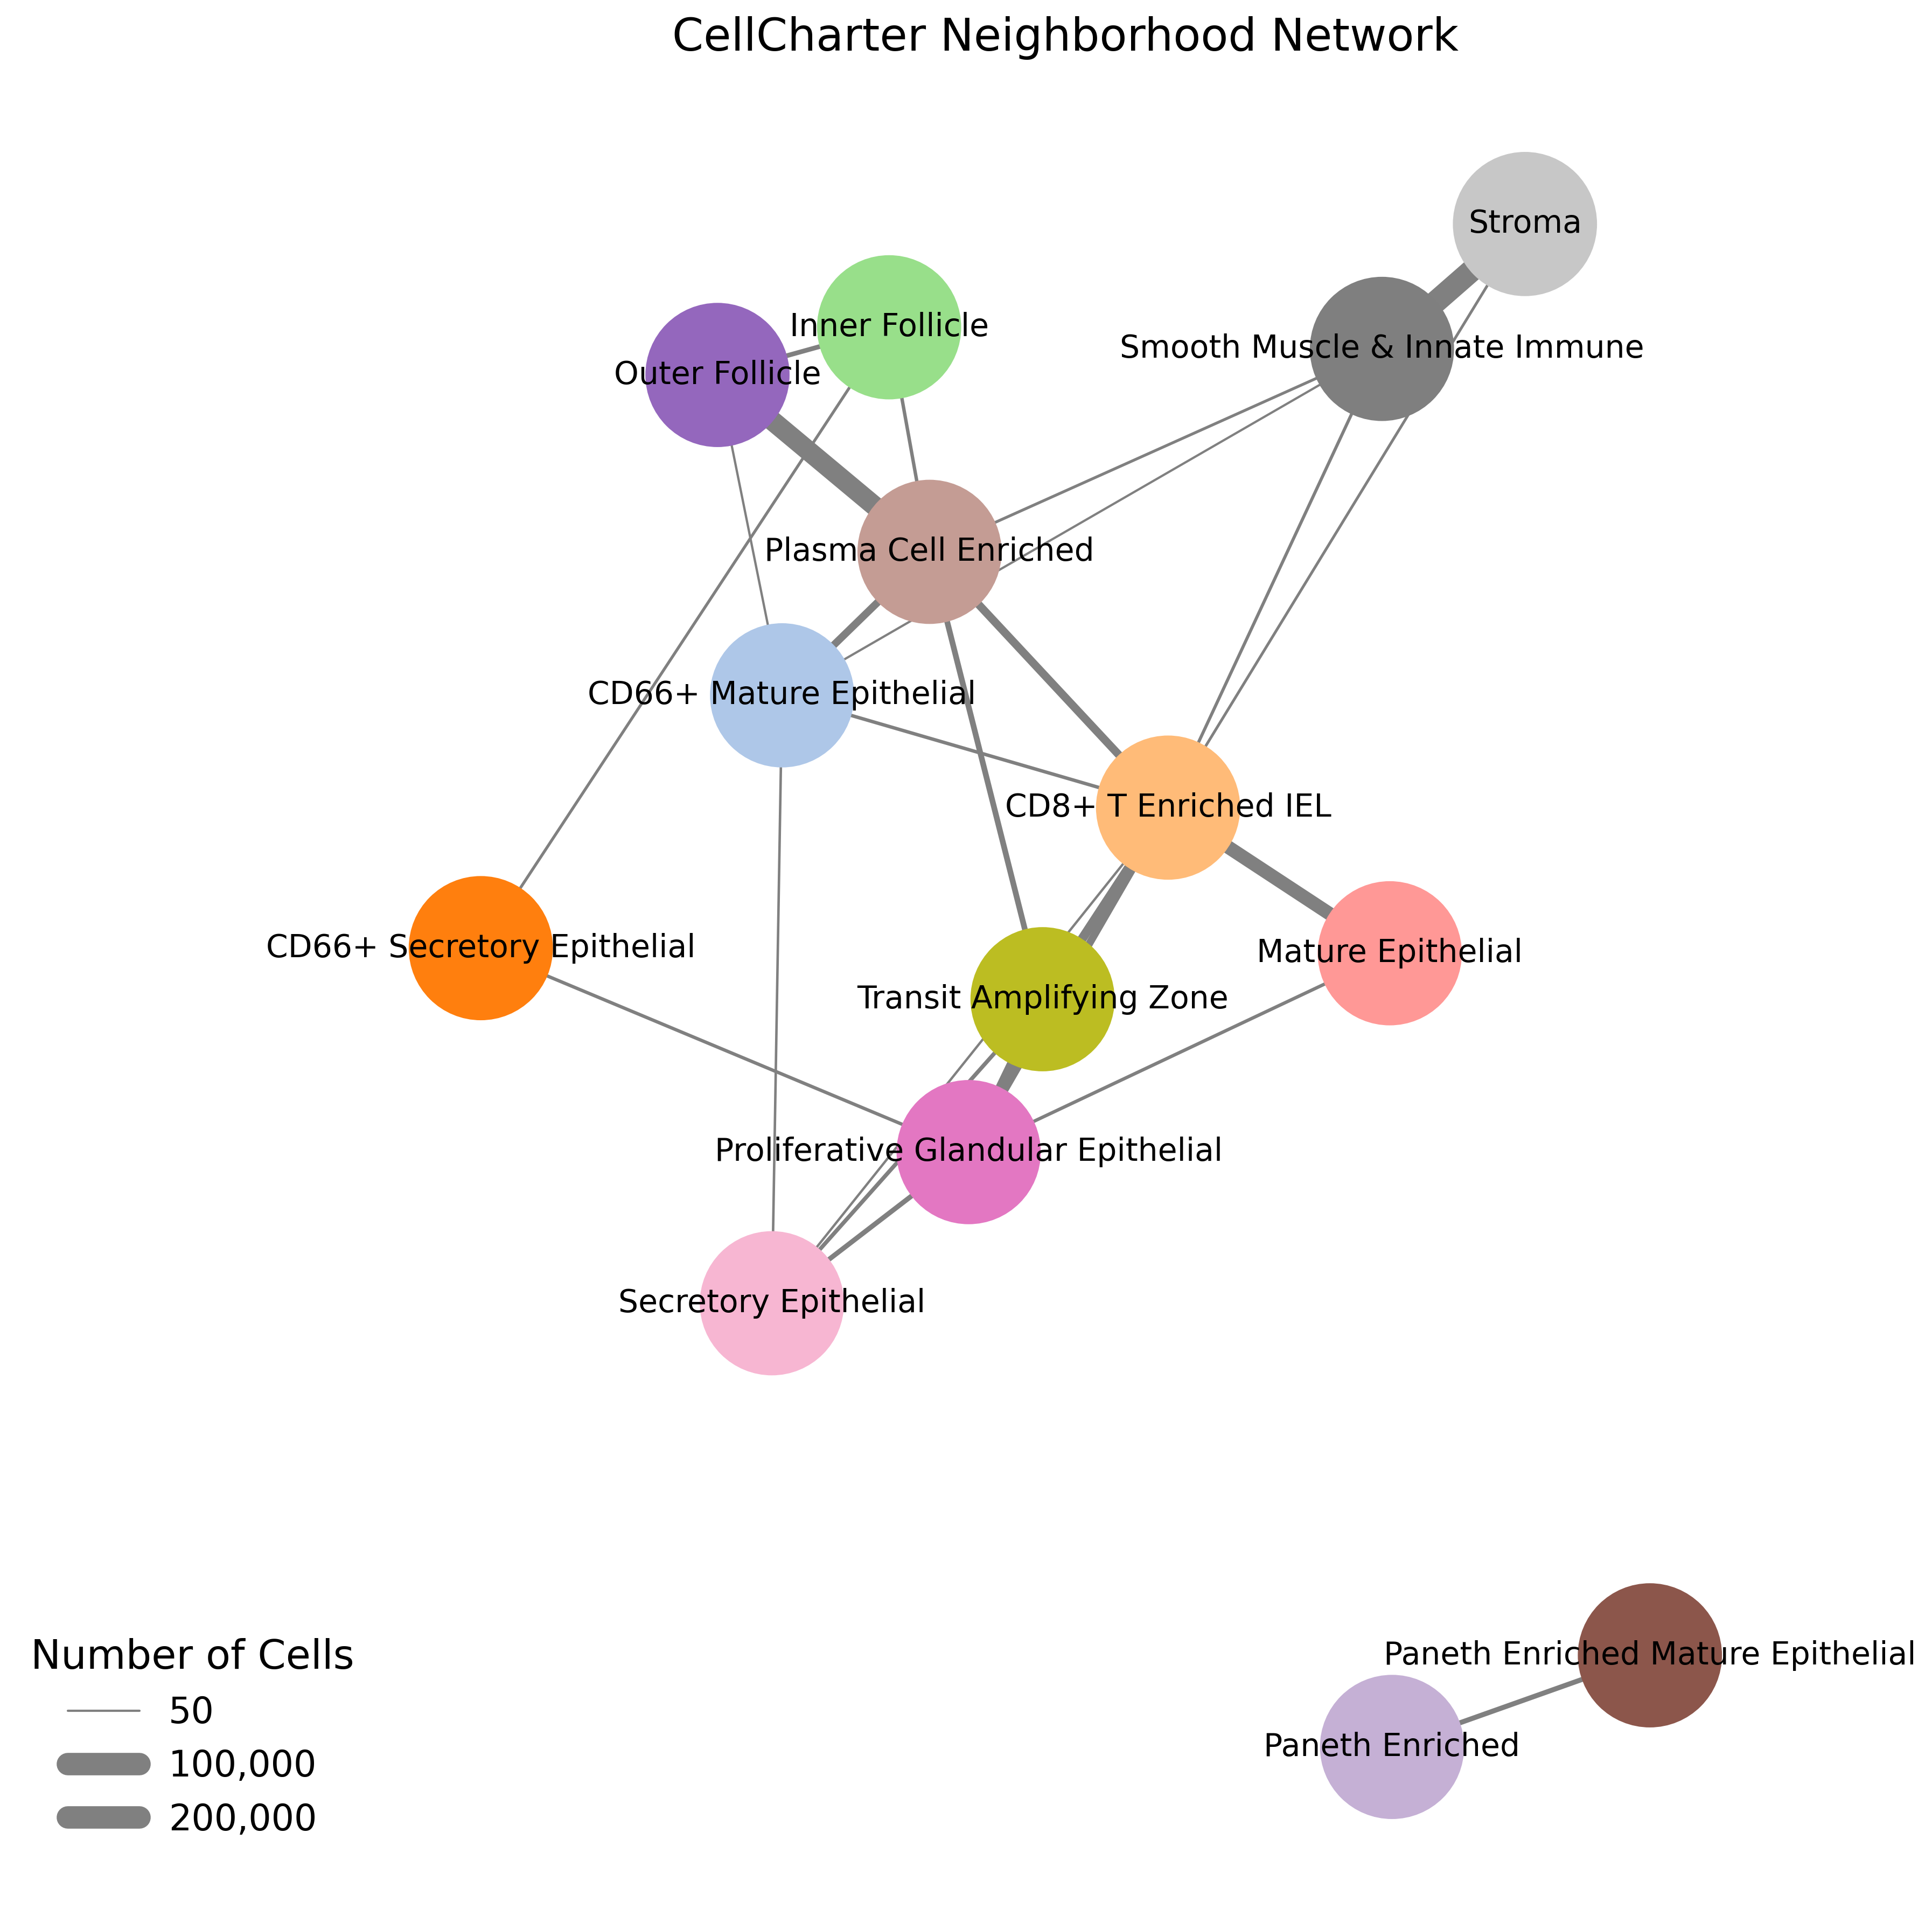

In [44]:
G, top_pairs = (
    mg.tl.network_graphs.build_neighborhood_pair_graph(
        cells_mingl,
        prob_cols=prob_cols,
        threshold=0.25,
        region_key="unique_region",
        top_n=25,
        uns_key="cellcharter_neighborhood_pair_graph_updated",
    )
)

# mg.tl.network_graphs.plot_neighborhood_pair_graph(
#     cells_mingl,
#     edge_legend_values=[50, 100_000, 200_000],
#     title="CellCharter Neighborhood Network",
#     uns_key="cellcharter_neighborhood_pair_graph",
#     seed=32,
#     layout_k=20,
#     edge_legend_loc= "lower left",
#     node_color=CC_neigh_dict,
# )

import matplotlib.pyplot as plt
from matplotlib.collections import PathCollection
from IPython.display import display

# Use your existing palette for both plots
neighborhood_color_map = {
    str(label): color
    for label, color in CC_neigh_dict.items()
}

uns_key = "cellcharter_neighborhood_pair_graph_updated"
G = cells_mingl.uns[uns_key]["graph"]

missing = [
    node for node in G.nodes()
    if str(node) not in neighborhood_color_map
]
if missing:
    raise ValueError(f"Missing neighborhood colors: {missing}")

node_colors = [
    neighborhood_color_map[str(node)]
    for node in G.nodes()
]

# Create the figure without displaying the original colors
with plt.ioff():
    original_show = plt.show

    try:
        plt.show = lambda *args, **kwargs: None

        fig = mg.tl.network_graphs.plot_neighborhood_pair_graph(
            cells_mingl,
            edge_legend_values=[50, 100_000, 200_000],
            title="CellCharter Neighborhood Network",
            uns_key=uns_key,
            seed=42,
            layout_k=15,
            edge_legend_loc="lower right",
            edge_legend_bbox=(0.02, 0.02),
            edge_color="gray",
            return_fig=True,
        )

    finally:
        plt.show = original_show

    # Replace the node colors with your neighborhood palette
    ax = fig.axes[0]

    node_collection = next(
        collection
        for collection in ax.collections
        if isinstance(collection, PathCollection)
    )

    node_collection.set_facecolor(node_colors)

display(fig)
plt.close(fig)

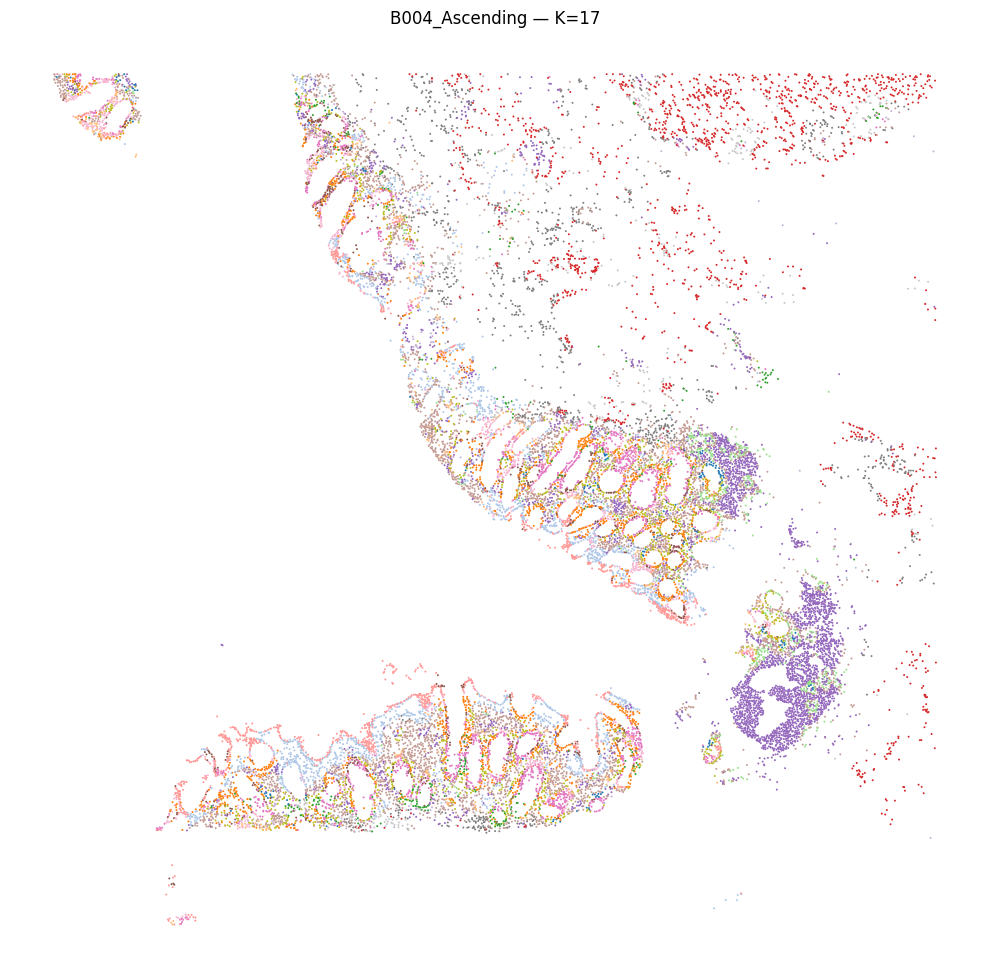

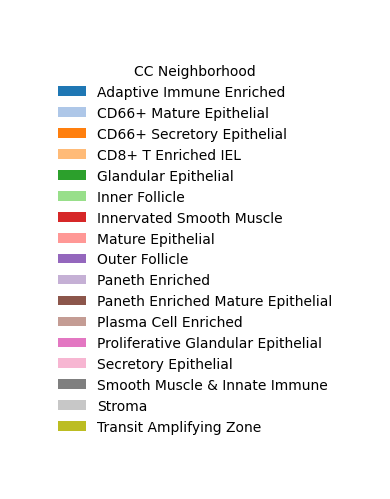

In [38]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

region = "B004_Ascending"

mask = cells_mingl.obs["unique_region"].eq(region).to_numpy()

coords = np.asarray(cells_mingl.obsm["spatial"])[mask]

labels = cells_mingl.obs.loc[
    mask, "CC_Neighborhood_Label_Updated"
].astype(str)

# SAME palette used for the network nodes
neighborhood_color_map = {
    str(label): color
    for label, color in CC_neigh_dict.items()
}

all_neighborhoods = sorted(neighborhood_color_map)
n_neighborhoods = len(all_neighborhoods)

point_colors = [
    neighborhood_color_map[label]
    for label in labels
]

# Plot spatial neighborhoods
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=point_colors,
    s=2,
    linewidths=0,
    rasterized=True,
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title(f"{region} — K={n_neighborhoods}")
ax.axis("off")

plt.tight_layout()
plt.show()

# Separate legend figure, using the same palette
legend_handles = [
    Patch(
        facecolor=neighborhood_color_map[neighborhood],
        edgecolor="none",
        label=neighborhood,
    )
    for neighborhood in all_neighborhoods
]

legend_fig, legend_ax = plt.subplots(
    figsize=(4, max(3, n_neighborhoods * 0.3))
)

legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    title="CC Neighborhood",
    loc="center",
    frameon=False,
)

plt.tight_layout()
plt.show()

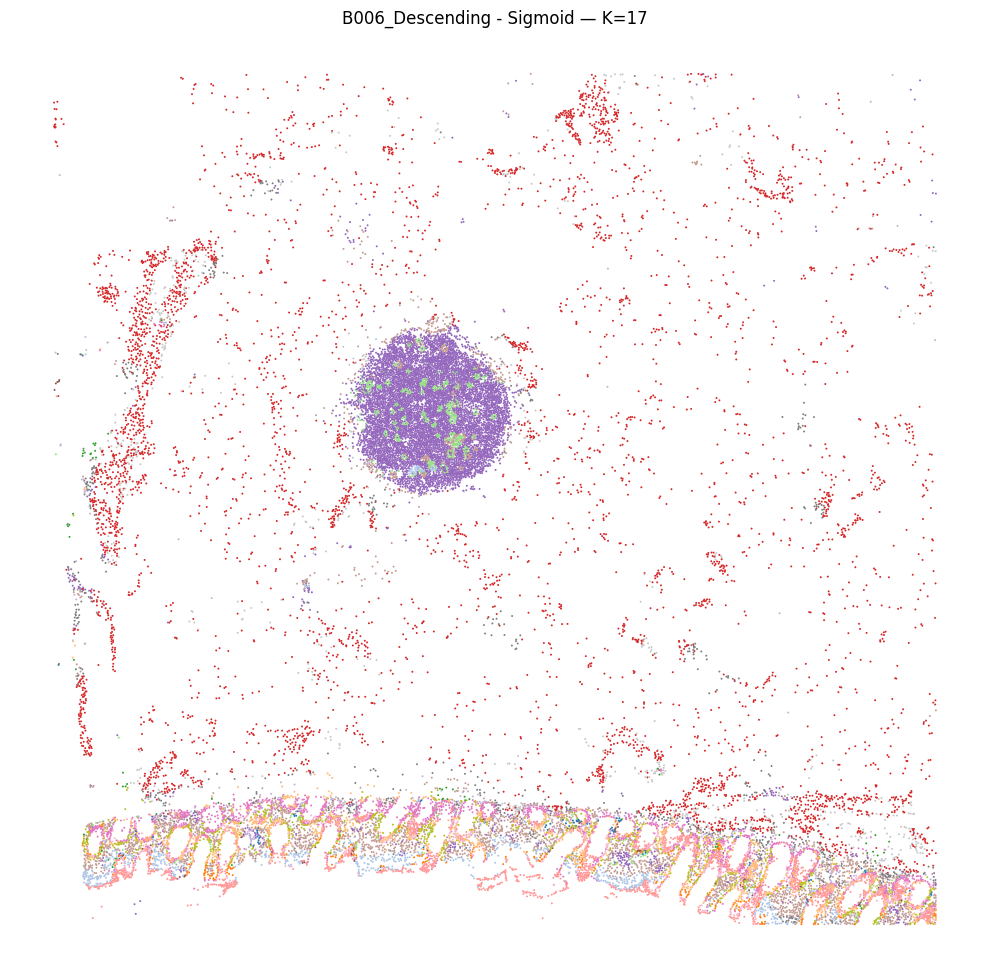

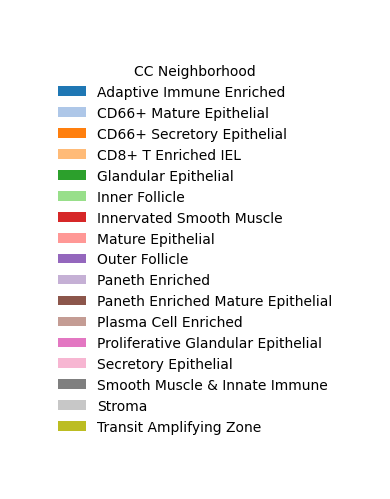

In [40]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

region = "B006_Descending - Sigmoid"

mask = cells_mingl.obs["unique_region"].eq(region).to_numpy()

coords = np.asarray(cells_mingl.obsm["spatial"])[mask]

labels = cells_mingl.obs.loc[
    mask, "CC_Neighborhood_Label_Updated"
].astype(str)

# SAME palette used for the network nodes
neighborhood_color_map = {
    str(label): color
    for label, color in CC_neigh_dict.items()
}

all_neighborhoods = sorted(neighborhood_color_map)
n_neighborhoods = len(all_neighborhoods)

point_colors = [
    neighborhood_color_map[label]
    for label in labels
]

# Plot spatial neighborhoods
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=point_colors,
    s=2,
    linewidths=0,
    rasterized=True,
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title(f"{region} — K={n_neighborhoods}")
ax.axis("off")

plt.tight_layout()
plt.show()

# Separate legend figure, using the same palette
legend_handles = [
    Patch(
        facecolor=neighborhood_color_map[neighborhood],
        edgecolor="none",
        label=neighborhood,
    )
    for neighborhood in all_neighborhoods
]

legend_fig, legend_ax = plt.subplots(
    figsize=(4, max(3, n_neighborhoods * 0.3))
)

legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    title="CC Neighborhood",
    loc="center",
    frameon=False,
)

plt.tight_layout()
plt.show()

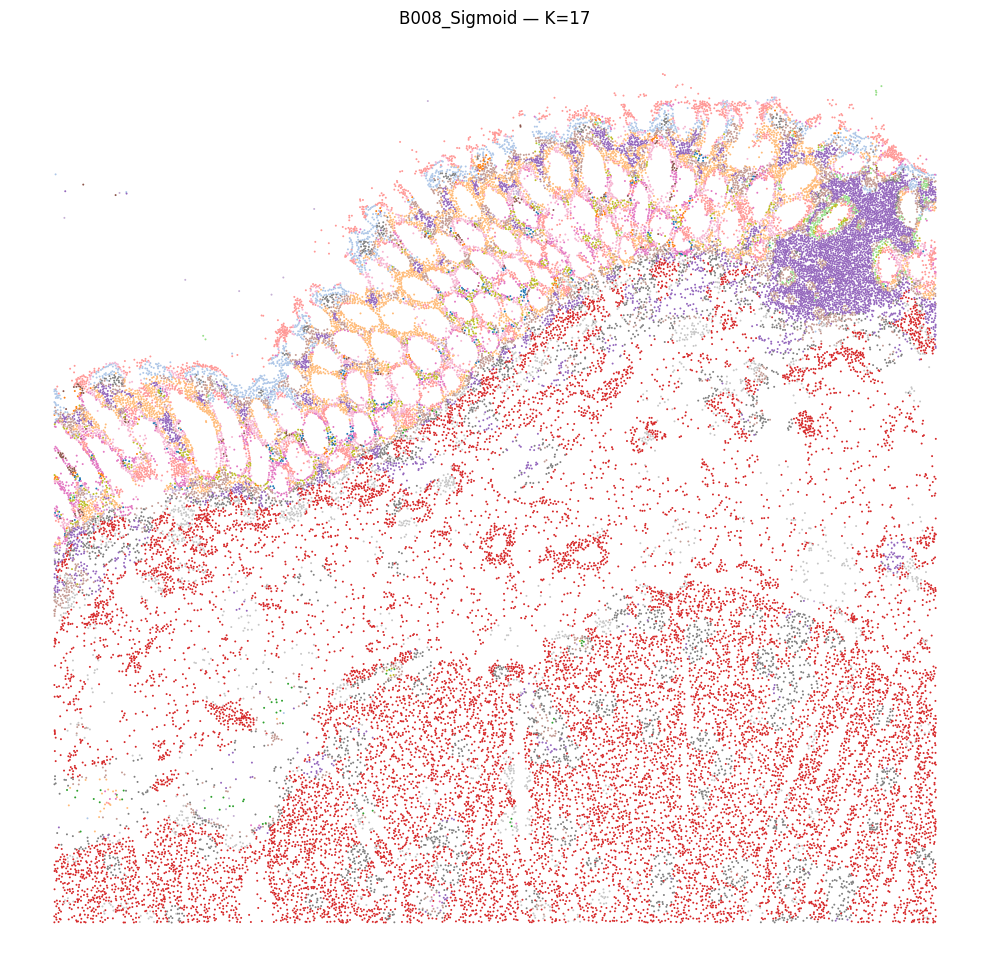

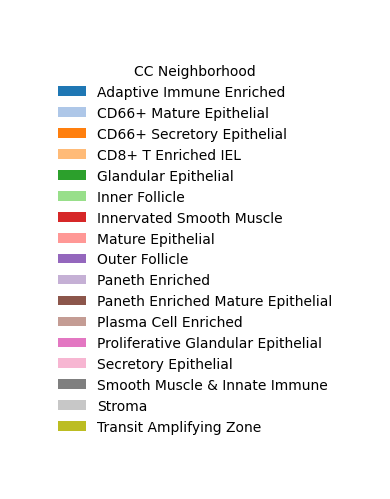

In [41]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

region = "B008_Sigmoid"

mask = cells_mingl.obs["unique_region"].eq(region).to_numpy()

coords = np.asarray(cells_mingl.obsm["spatial"])[mask]

labels = cells_mingl.obs.loc[
    mask, "CC_Neighborhood_Label_Updated"
].astype(str)

# SAME palette used for the network nodes
neighborhood_color_map = {
    str(label): color
    for label, color in CC_neigh_dict.items()
}

all_neighborhoods = sorted(neighborhood_color_map)
n_neighborhoods = len(all_neighborhoods)

point_colors = [
    neighborhood_color_map[label]
    for label in labels
]

# Plot spatial neighborhoods
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=point_colors,
    s=2,
    linewidths=0,
    rasterized=True,
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title(f"{region} — K={n_neighborhoods}")
ax.axis("off")

plt.tight_layout()
plt.show()

# Separate legend figure, using the same palette
legend_handles = [
    Patch(
        facecolor=neighborhood_color_map[neighborhood],
        edgecolor="none",
        label=neighborhood,
    )
    for neighborhood in all_neighborhoods
]

legend_fig, legend_ax = plt.subplots(
    figsize=(4, max(3, n_neighborhoods * 0.3))
)

legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    title="CC Neighborhood",
    loc="center",
    frameon=False,
)

plt.tight_layout()
plt.show()

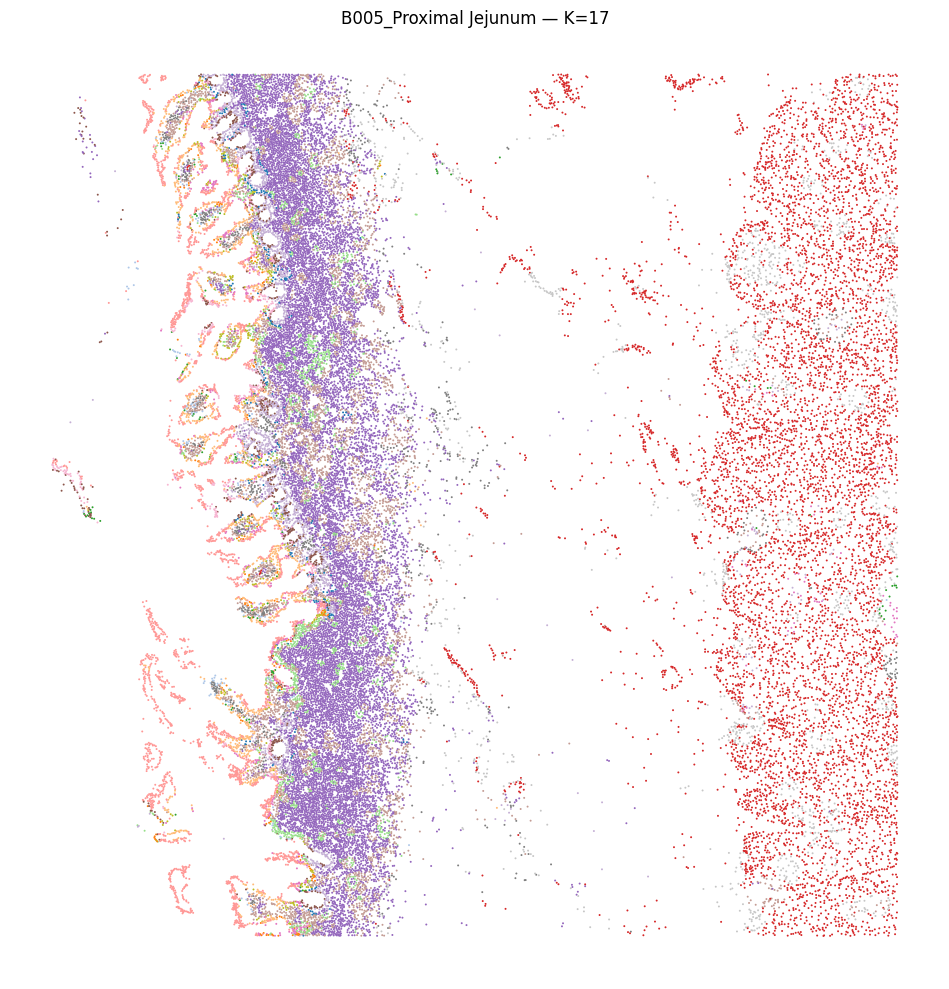

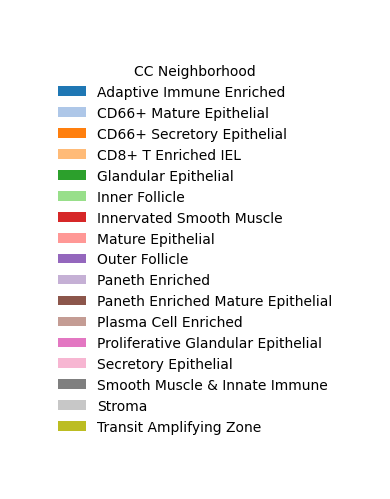

In [42]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

region = "B005_Proximal Jejunum"

mask = cells_mingl.obs["unique_region"].eq(region).to_numpy()

coords = np.asarray(cells_mingl.obsm["spatial"])[mask]

labels = cells_mingl.obs.loc[
    mask, "CC_Neighborhood_Label_Updated"
].astype(str)

# SAME palette used for the network nodes
neighborhood_color_map = {
    str(label): color
    for label, color in CC_neigh_dict.items()
}

all_neighborhoods = sorted(neighborhood_color_map)
n_neighborhoods = len(all_neighborhoods)

point_colors = [
    neighborhood_color_map[label]
    for label in labels
]

# Plot spatial neighborhoods
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=point_colors,
    s=2,
    linewidths=0,
    rasterized=True,
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title(f"{region} — K={n_neighborhoods}")
ax.axis("off")

plt.tight_layout()
plt.show()

# Separate legend figure, using the same palette
legend_handles = [
    Patch(
        facecolor=neighborhood_color_map[neighborhood],
        edgecolor="none",
        label=neighborhood,
    )
    for neighborhood in all_neighborhoods
]

legend_fig, legend_ax = plt.subplots(
    figsize=(4, max(3, n_neighborhoods * 0.3))
)

legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    title="CC Neighborhood",
    loc="center",
    frameon=False,
)

plt.tight_layout()
plt.show()

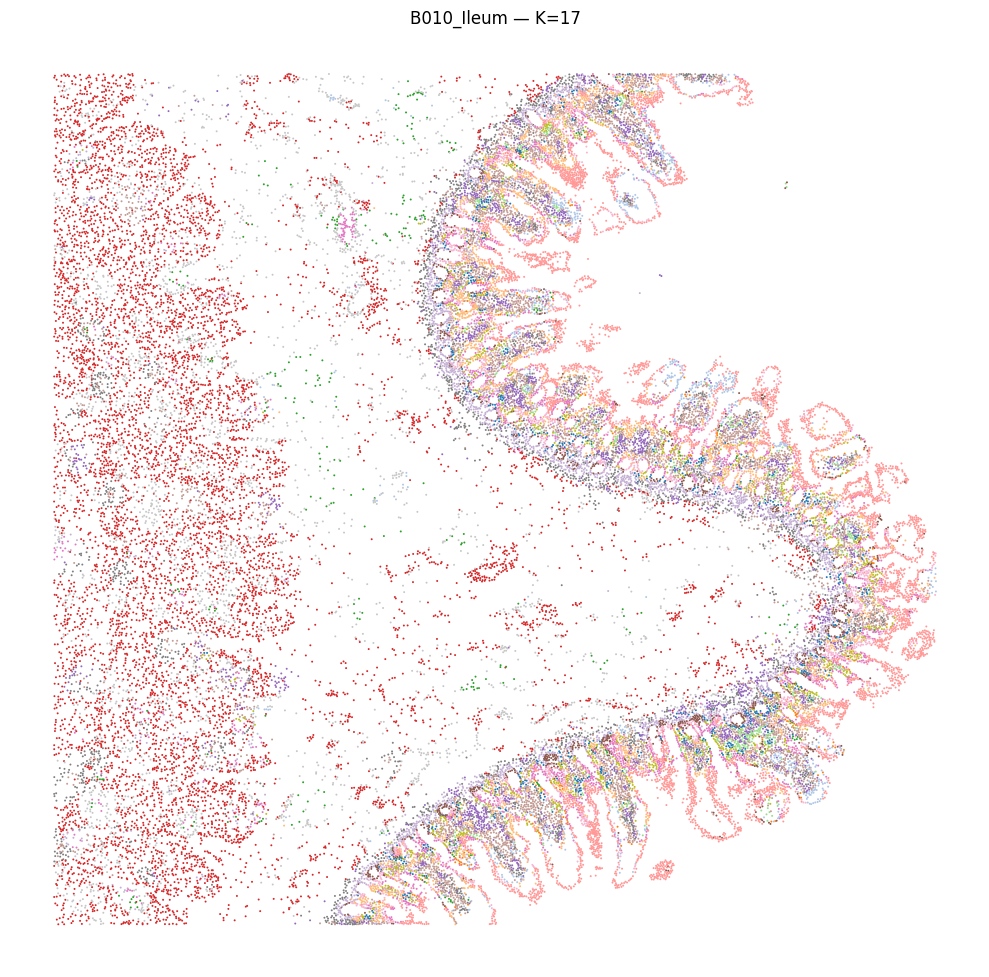

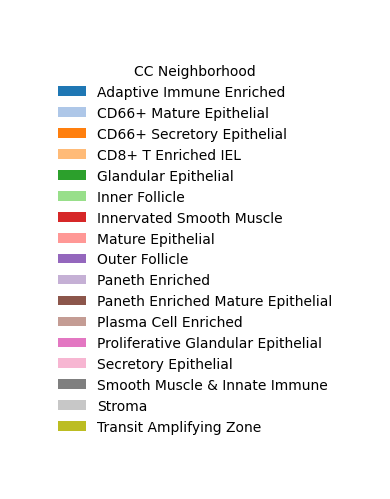

In [45]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

region = "B010_Ileum"

mask = cells_mingl.obs["unique_region"].eq(region).to_numpy()

coords = np.asarray(cells_mingl.obsm["spatial"])[mask]

labels = cells_mingl.obs.loc[
    mask, "CC_Neighborhood_Label_Updated"
].astype(str)

# SAME palette used for the network nodes
neighborhood_color_map = {
    str(label): color
    for label, color in CC_neigh_dict.items()
}

all_neighborhoods = sorted(neighborhood_color_map)
n_neighborhoods = len(all_neighborhoods)

point_colors = [
    neighborhood_color_map[label]
    for label in labels
]

# Plot spatial neighborhoods
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=point_colors,
    s=2,
    linewidths=0,
    rasterized=True,
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title(f"{region} — K={n_neighborhoods}")
ax.axis("off")

plt.tight_layout()
plt.show()

# Separate legend figure, using the same palette
legend_handles = [
    Patch(
        facecolor=neighborhood_color_map[neighborhood],
        edgecolor="none",
        label=neighborhood,
    )
    for neighborhood in all_neighborhoods
]

legend_fig, legend_ax = plt.subplots(
    figsize=(4, max(3, n_neighborhoods * 0.3))
)

legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    title="CC Neighborhood",
    loc="center",
    frameon=False,
)

plt.tight_layout()
plt.show()

In [22]:
cells_mingl.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 2512002 × 25
    obs: 'Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit', 'cc_K21', 'cc_K22', 'cc_K23', 'cellcharter_clusters', 'spatial_cluster', 'cc_nofoc

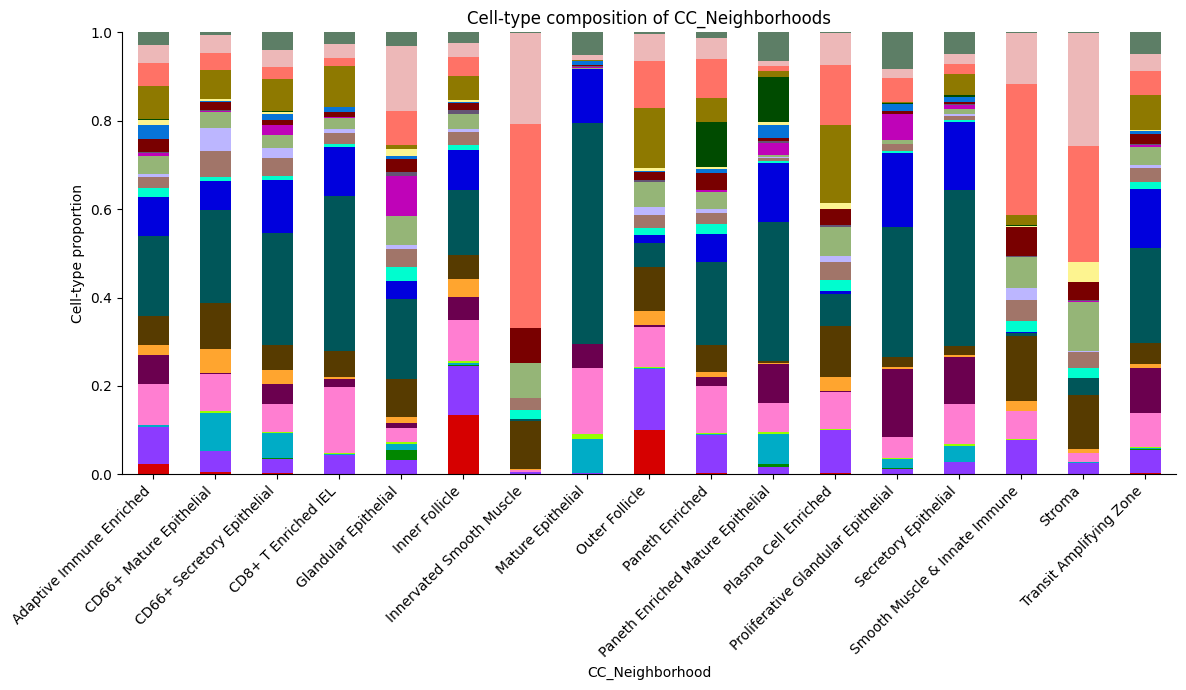

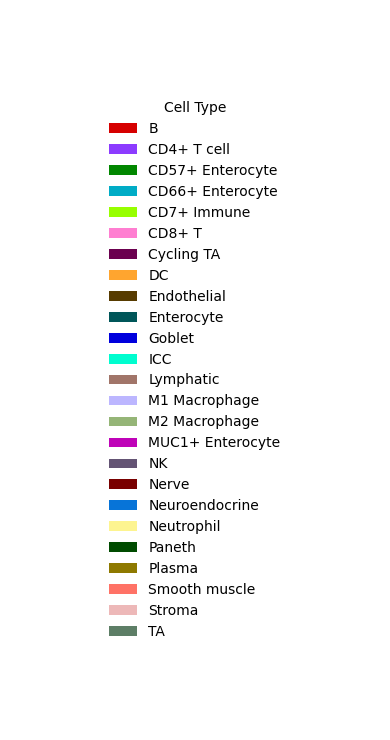

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import colorcet as cc

cell_type_col = "Cell Type"
adata_plot = cells_mingl
color_map = color_dict

plot_df = adata_plot.obs[
    ["CC_Neighborhood_Label", cell_type_col]
].dropna()

proportions = pd.crosstab(
    plot_df["CC_Neighborhood_Label"],
    plot_df[cell_type_col],
    normalize="index"
)

# Distinct categorical colors
n_cell_types = proportions.shape[1]
colors = cc.glasbey[:n_cell_types]

color_map = dict(zip(proportions.columns, colors))

# Main stacked-bar figure
fig, ax = plt.subplots(figsize=(12, 7))

proportions.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[color_map[cell_type] for cell_type in proportions.columns],
    edgecolor="none",
    legend=False
)

ax.set_xlabel("CC_Neighborhood")
ax.set_ylabel("Cell-type proportion")
ax.set_title("Cell-type composition of CC_Neighborhoods")
ax.set_ylim(0, 1)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Separate legend figure
legend_handles = [
    Patch(
        facecolor=color_map[cell_type],
        edgecolor="none",
        label=cell_type
    )
    for cell_type in proportions.columns
]

legend_fig, legend_ax = plt.subplots(
    figsize=(4, max(2, n_cell_types * 0.3))
)

legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    title="Cell Type",
    loc="center",
    frameon=False
)

plt.tight_layout()
plt.show()

C:\Users\k1van\AppData\Local\Temp\ipykernel_36356\98506753.py:73: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_ct.obs[group_key] = adata_ct.obs[group_key].astype("category")


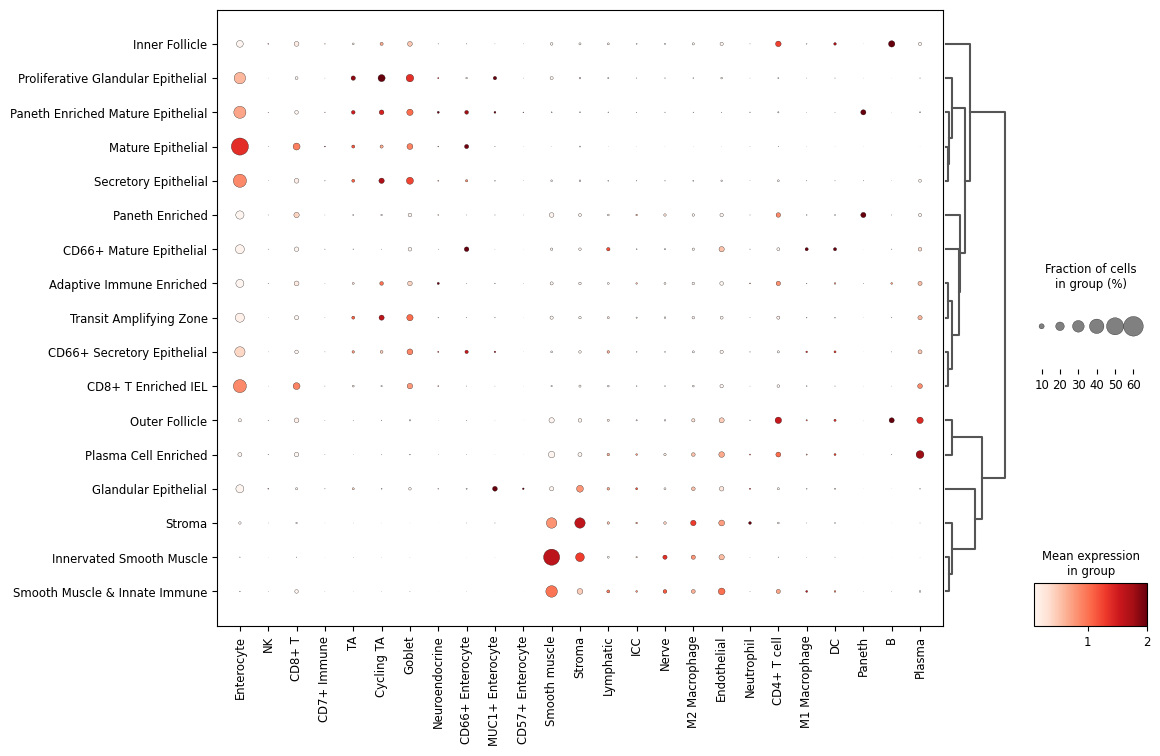

In [30]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.cluster.hierarchy import linkage, leaves_list

# ============================================================
# Cell-type enrichment by CC_Neighborhood
# ============================================================

group_key = "CC_Neighborhood_Label"
celltype_key = "Cell Type"

# Cell types
celltype_list = list(
    cells_mingl.obs[celltype_key].astype(str).unique()
)

# Binary cell-type matrix
celltype_binary = pd.get_dummies(
    cells_mingl.obs[celltype_key].astype(str)
)[celltype_list]

# Temporary AnnData object for the dot plot
# Temporary AnnData object for the dot plot
adata_ct = ad.AnnData(
    X=celltype_binary.values.astype(float),
    obs=pd.DataFrame(
        {
            group_key: cells_mingl.obs[group_key].astype(str).values
        },
        index=cells_mingl.obs_names
    ),
    var=pd.DataFrame(index=celltype_list)
)

adata_ct.obs[group_key] = adata_ct.obs[group_key].astype("category")

# Cell-type proportions within each neighborhood
proportions = (
    celltype_binary
    .assign(**{group_key: cells_mingl.obs[group_key].values})
    .groupby(group_key, observed=True)[celltype_list]
    .mean()
)

# Overall cell-type frequency
global_frequency = celltype_binary.mean(axis=0)

# Log2 enrichment relative to the overall dataset
enrichment = np.log2(
    (proportions + 1e-6) /
    (global_frequency + 1e-6)
)

# Cluster cell types based on their enrichment profiles
linkage_matrix = linkage(
    enrichment.T.values,
    method="ward",
    metric="euclidean"
)

ordered_celltypes = [
    enrichment.columns[i]
    for i in leaves_list(linkage_matrix)
]

# Reorder cell types
adata_ct = adata_ct[:, ordered_celltypes]
enrichment = enrichment[ordered_celltypes]

# Ensure the grouping variable is categorical
adata_ct.obs[group_key] = adata_ct.obs[group_key].astype("category")

# Calculate the neighborhood dendrogram
sc.tl.dendrogram(
    adata_ct,
    groupby=group_key,
    use_rep="X"
)

# Plot dot plot
sc.pl.dotplot(
    adata_ct,
    var_names=ordered_celltypes,
    groupby=group_key,
    vmax=2,
    vmin=0.1,
    expression_cutoff=0,
    dendrogram=True,
    swap_axes=False,
    dot_color_df=enrichment,
    figsize=(12, 8)
)

show specific connections

In [59]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_cellcharter_connection(
    adata,
    node_a,
    node_b,
    *,
    color_map,
    uns_key="cellcharter_neighborhood_pair_graph_updated",
    figsize=(8, 4),
    node_size=4000,
    font_size=15,
):
    # Search all counted pairs, including those outside the top_n graph
    pairs = adata.uns[uns_key]["pair_counts_summed"]

    match = pairs.loc[
        (
            (pairs["Neighborhood1"] == node_a)
            & (pairs["Neighborhood2"] == node_b)
        )
        | (
            (pairs["Neighborhood1"] == node_b)
            & (pairs["Neighborhood2"] == node_a)
        )
    ]

    if match.empty:
        raise ValueError(
            f"No counted connection found between {node_a!r} and {node_b!r}."
        )

    count = int(match["count"].sum())

    palette = {str(key): value for key, value in color_map.items()}
    missing = [
        node for node in (node_a, node_b)
        if str(node) not in palette
    ]
    if missing:
        raise ValueError(f"Missing neighborhood colors: {missing}")

    pair_graph = nx.Graph()
    pair_graph.add_edge(node_a, node_b, weight=count)

    # Fixed positions make individual connections easy to compare
    pos = {
        node_a: (-1, 0),
        node_b: (1, 0),
    }

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_nodes(
        pair_graph,
        pos,
        nodelist=[node_a, node_b],
        node_color=[palette[str(node_a)], palette[str(node_b)]],
        node_size=node_size,
        ax=ax,
    )

    nx.draw_networkx_edges(
        pair_graph,
        pos,
        edge_color="gray",
        width=4,
        ax=ax,
    )

    nx.draw_networkx_labels(
        pair_graph,
        pos,
        font_size=font_size,
        ax=ax,
    )

    nx.draw_networkx_edge_labels(
        pair_graph,
        pos,
        edge_labels={(node_a, node_b): f"{count:,} cells"},
        font_size=15,
        ax=ax,
    )

    ax.set_title("CellCharter Neighborhood Connection")
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-0.6, 0.6)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return fig

['Plasma Cell Enriched', 'Proliferative Glandular Epithelial', 'Outer Follicle', 'Mature Epithelial', 'Adaptive Immune Enriched', 'Secretory Epithelial', 'Transit Amplifying Zone', 'Glandular Epithelial', 'CD66+ Mature Epithelial', 'Paneth Enriched', 'Stroma', 'Smooth Muscle & Innate Immune', 'CD66+ Secretory Epithelial', 'CD8+ T Enriched IEL', 'Paneth Enriched Mature Epithelial', 'Inner Follicle', 'Innervated Smooth Muscle']


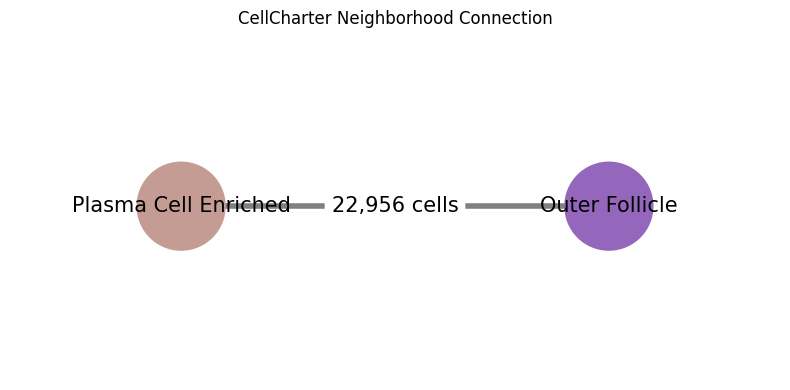

In [60]:
# View available neighborhood names
print(prob_cols)

fig = plot_cellcharter_connection(
    cells_mingl,
    node_a="Plasma Cell Enriched",
    node_b="Outer Follicle",
    color_map=CC_neigh_dict,
)

In [57]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def plot_selected_connection(
    adata,
    node_a,
    node_b,
    *,
    color_map,
    uns_key="neighborhood_pair_graph",
    figsize=(8, 4),
    node_size=4000,
    font_size=15,
):
    G = adata.uns[uns_key]["graph"]

    if node_a == node_b:
        raise ValueError("Select two different nodes.")

    if not G.has_edge(node_a, node_b):
        raise ValueError(
            f"No edge between {node_a!r} and {node_b!r} "
            f"in the stored graph."
        )

    # Same normalization as your existing manuscript code:
    # use ALL edges in the original graph.
    edge_list = list(G.edges())
    edge_counts = np.array(
        [G[u][v]["weight"] for u, v in edge_list],
        dtype=float,
    )

    _eps = 1e-9

    if edge_counts.max() > 0:
        enrichments = edge_counts / edge_counts.max()
    else:
        enrichments = np.full_like(edge_counts, _eps)

    min_width_vis = 1.0
    max_width_vis = 8.0

    e_min = float(enrichments.min())
    e_max = float(enrichments.max())

    if e_max == e_min:
        e_min = max(0.0, e_min - 1e-6)
        e_max = e_min + 1e-6

    def to_width(e):
        return (
            min_width_vis
            + (e - e_min) / (e_max - e_min)
            * (max_width_vis - min_width_vis)
        )

    count = float(G[node_a][node_b]["weight"])
    scaled_value = (
        count / edge_counts.max()
        if edge_counts.max() > 0
        else _eps
    )

    # Draw only the selected connection.
    selected_graph = nx.Graph()
    selected_graph.add_edge(node_a, node_b, weight=count)

    pos = {
        node_a: (-1, 0),
        node_b: (1, 0),
    }

    palette = {str(key): value for key, value in color_map.items()}

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_edges(
        selected_graph,
        pos,
        edge_color="gray",
        width=to_width(scaled_value),
        arrows=False,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        selected_graph,
        pos,
        nodelist=[node_a, node_b],
        node_color=[
            palette.get(str(node_a), "lightgray"),
            palette.get(str(node_b), "lightgray"),
        ],
        node_size=node_size,
        linewidths=0,
        ax=ax,
    )

    nx.draw_networkx_edge_labels(
        selected_graph,
        pos,
        edge_labels={(node_a, node_b): f"{scaled_value:.3f}"},
        font_size=font_size,
        ax=ax,
    )

    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-0.6, 0.6)
    ax.axis("off")

    fig.tight_layout()
    plt.show()

    return fig

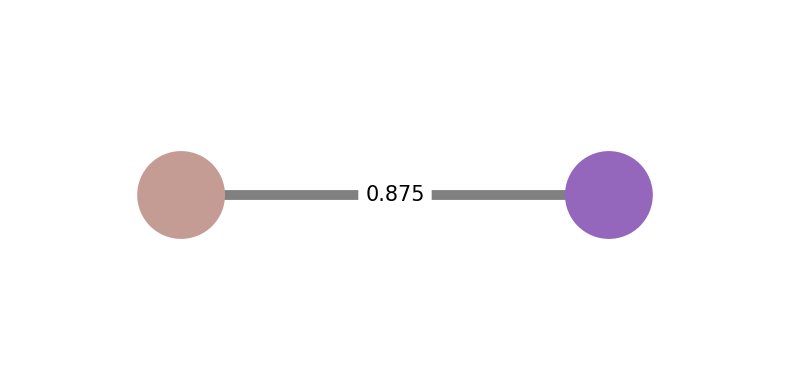

In [58]:
fig = plot_selected_connection(
    cells_mingl,
    "Plasma Cell Enriched",
    "Outer Follicle",
    color_map=CC_neigh_dict,
    uns_key="cellcharter_neighborhood_pair_graph_updated",
)

In [31]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_cellcharter_subset(
    adata,
    neighborhoods,
    *,
    color_map,
    uns_key="cellcharter_neighborhood_pair_graph",
    seed=32,
    layout_k=2,
    figsize=(10, 8),
    node_size=4000,
    font_size=12,
    edge_legend_values=(100, 1000, 10000),
    edge_legend_loc="lower left",
):
    neighborhoods = list(dict.fromkeys(str(n) for n in neighborhoods))

    if not neighborhoods:
        raise ValueError("Provide at least one neighborhood.")

    palette = {str(k): v for k, v in color_map.items()}
    missing = [n for n in neighborhoods if n not in palette]
    if missing:
        raise ValueError(f"Neighborhoods missing from the palette: {missing}")

    # Include all counted connections, even those outside the original top_n
    pairs = adata.uns[uns_key]["pair_counts_summed"].copy()
    pairs["Neighborhood1"] = pairs["Neighborhood1"].astype(str)
    pairs["Neighborhood2"] = pairs["Neighborhood2"].astype(str)

    selected_pairs = pairs.loc[
        pairs["Neighborhood1"].isin(neighborhoods)
        & pairs["Neighborhood2"].isin(neighborhoods)
    ].copy()

    subset_G = nx.Graph()
    subset_G.add_nodes_from(neighborhoods)

    for _, row in selected_pairs.iterrows():
        subset_G.add_edge(
            row["Neighborhood1"],
            row["Neighborhood2"],
            weight=int(row["count"]),
        )

    pos = nx.spring_layout(subset_G, seed=seed, k=layout_k)

    # Use the full network's count range to keep widths consistent
    # across different subsets
    widths = []

    if subset_G.number_of_edges():
        all_weights = pairs["count"].to_numpy(dtype=float)
        w_min, w_max = all_weights.min(), all_weights.max()

        def to_width(value):
            if w_max > w_min:
                return 1 + 9 * (value - w_min) / (w_max - w_min)
            return 4.0

        widths = [
            to_width(data["weight"])
            for _, _, data in subset_G.edges(data=True)
        ]

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_nodes(
        subset_G,
        pos,
        nodelist=neighborhoods,
        node_color=[palette[n] for n in neighborhoods],
        node_size=node_size,
        ax=ax,
    )

    nx.draw_networkx_edges(
        subset_G,
        pos,
        edge_color="gray",
        width=widths,
        ax=ax,
    )

    nx.draw_networkx_labels(
        subset_G,
        pos,
        font_size=font_size,
        ax=ax,
    )

    # Edge-width legend; no counts displayed on the edges
    if subset_G.number_of_edges() and edge_legend_values is not None:
        legend_values = [
            value for value in edge_legend_values
            if w_min <= value <= w_max
        ]

        legend_handles = [
            Line2D(
                [],
                [],
                color="gray",
                linewidth=to_width(value),
                solid_capstyle="round",
                label=f"{value:,.0f}",
            )
            for value in legend_values
        ]

        if legend_handles:
            ax.legend(
                handles=legend_handles,
                title="Number of Cells",
                loc=edge_legend_loc,
                frameon=False,
                fontsize=12,
                title_fontsize=14,
                labelspacing=1.2,
                handlelength=3,
            )

    ax.set_title("CellCharter Subset Network")
    ax.margins(0.25)
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return subset_G, selected_pairs, fig


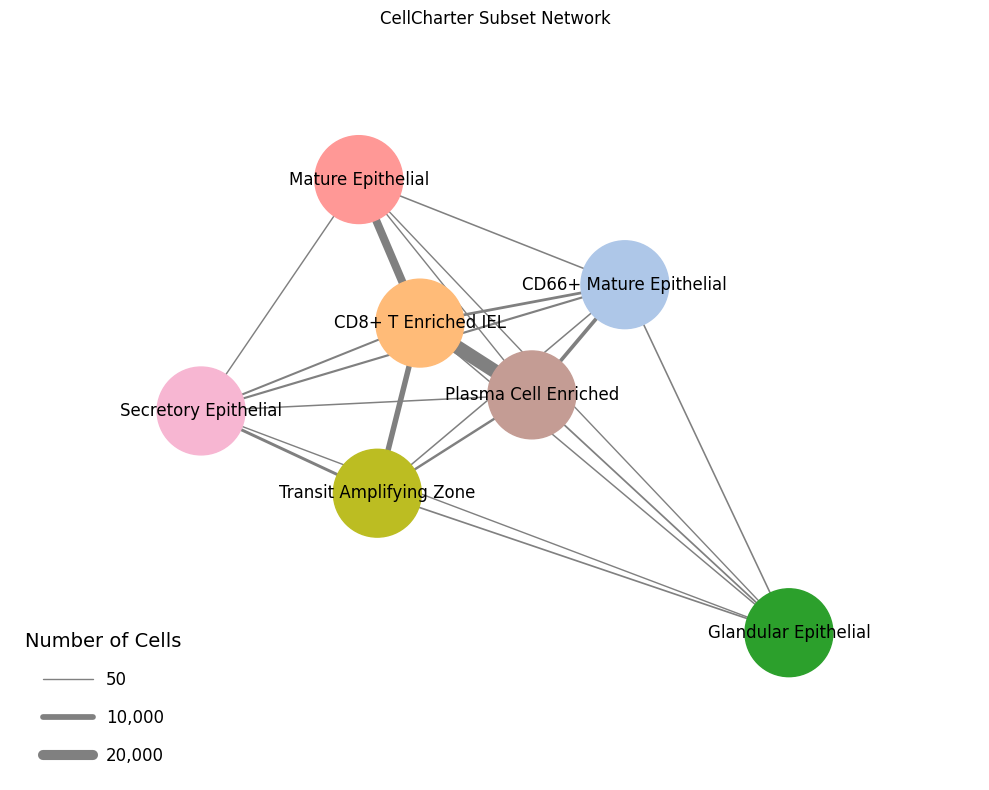

In [38]:
selected_neighborhoods = [
    "Glandular Epithelial",
    "Mature Epithelial",
    "CD66+ Mature Epithelial",
    "CD8+ T Enriched IEL",
    "Transit Amplifying Zone",
    "Secretory Epithelial",
    "Plasma Cell Enriched"
]

subset_G, subset_pairs, fig = plot_cellcharter_subset(
    cells_mingl,
    neighborhoods=selected_neighborhoods,
    color_map=CC_neigh_dict,
    edge_legend_values=[50, 10_000, 20_000],
    edge_legend_loc="lower left",
)

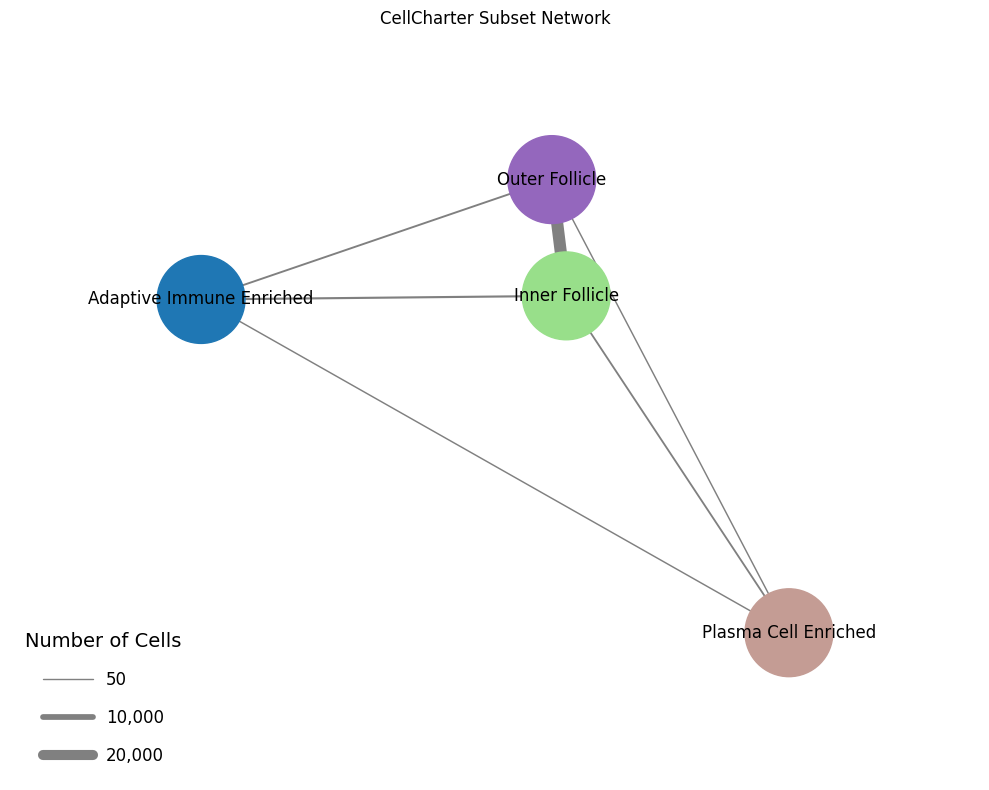

In [39]:
selected_neighborhoods = [
    "Plasma Cell Enriched",
    "Inner Follicle",
    "Outer Follicle",
    "Adaptive Immune Enriched",
]

subset_G, subset_pairs, fig = plot_cellcharter_subset(
    cells_mingl,
    neighborhoods=selected_neighborhoods,
    color_map=CC_neigh_dict,
    edge_legend_values=[50, 10_000, 20_000],
    edge_legend_loc="lower left",
)